In [5]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
current_dir = Path().resolve()
sys.path.append(current_dir.parent.parent.as_posix())

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

import utils
from data_io import DataIO
from psth_utils import *
from psth_params import *

# ── Paths ────────────────────────────────────────────────────
session_id = '260519_A'
data_dir   = Path(r'/media/aleong/Audrey-experiments1') / 'Experiments' / 'dataset'
figure_dir = data_dir / 'Figures_prr_series'
os.makedirs(figure_dir, exist_ok=True)

# ── Load session ─────────────────────────────────────────────
data_io  = DataIO(data_dir)
loadname = data_dir / f'{session_id}_cells.csv'
data_io.load_session(session_id, load_pickle=True, load_waveforms=False)
cells_df = pd.read_csv(loadname, header=[0, 1], index_col=0)
print('Session loaded.')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading pickled data (not from h5 file)
Session loaded.


## Select recordings and detect preferred electrode

In [6]:
# ── Select the 4 blocker-condition recordings ─────────────────
recording_nrs = [5, 7, 9, 11]  # noblocker, acet, acet+lap4, washout
selected_rec_names = []
for r in recording_nrs:
    for rec_id in data_io.recording_ids:
        if f'_{r:03d}_' in rec_id:
            selected_rec_names.append(rec_id)
            break

print('Selected recordings:')
for r in selected_rec_names:
    print(f'  {r}')

# ── Preferred electrode per cell ──────────────────────────────
# (electrode with the most significant responses across all trains)
pref_ec_dict = {}
for cluster_id in data_io.cluster_df.index.values:
    pref_ec, n_sig_pref_ec = None, None
    for ec in data_io.burst_df.electrode.unique():
        if pd.isna(ec):
            continue
        tids = data_io.burst_df.query(f'electrode == {float(ec)}').train_id.unique()
        n_sig = sum(
            1 for tid in tids
            if cells_df.loc[cluster_id, (tid, 'is_significant')] == True
        )
        if n_sig > 1 and (pref_ec is None or n_sig > n_sig_pref_ec):
            pref_ec, n_sig_pref_ec = ec, n_sig
    pref_ec_dict[cluster_id] = pref_ec

n_responsive = sum(1 for v in pref_ec_dict.values() if v is not None)
print(f'\nCells with a preferred electrode: {n_responsive} / {len(pref_ec_dict)}')

Selected recordings:
  260519_A_005_noblocker_pa_prr_series
  260519_A_007_acet_pa_prr_series
  260519_A_009_acet_lap4_pa_prr_series
  260519_A_011_washout_pa_prr_series

Cells with a preferred electrode: 185 / 186


## PSTH computation
For each cell × (blocker, PRR, power) combination: detect latency and response type.  
All results stored in `df` (significant responses only) and `zscore_store` (all conditions).

In [7]:
cluster_ids = data_io.cluster_df.index.values
all_results  = []
zscore_store = {}   # key: (cluster_id, blocker, prr, power)

for cluster_id in tqdm(cluster_ids):
    ec = pref_ec_dict.get(cluster_id)
    if ec is None:
        continue

    for rec_name in selected_rec_names:
        d_select = data_io.burst_df.query(
            'electrode == @ec and recording_name == @rec_name'
        ).copy()
        if d_select.empty:
            continue

        blocker  = d_select.Blocker.iloc[0]

        for prr in sorted(d_select.laser_pulse_repetition_rate.unique()):
            d_prr = d_select.query('laser_pulse_repetition_rate == @prr')

            for power in sorted(d_prr.laser_power.unique()):
                d_pow = d_prr.query('laser_power == @power')
                if d_pow.empty:
                    continue

                tid      = d_pow.iloc[0].train_id
                row0     = data_io.burst_df.query('train_id == @tid').iloc[0]
                rec_id   = str(row0.rec_id)
                stimtype = str(row0.stimtype)
                bd       = float(row0.laser_burst_duration)

                if stimtype in ('laser', 'padmd'):
                    burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values
                elif stimtype == 'dmd':
                    burst_onsets = data_io.burst_df.query('train_id == @tid').dmd_burst_onset.values
                else:
                    continue

                spiketrain = data_io.spiketimes[rec_id][cluster_id]

                # ── Bin spikes ─────────────────────────────────
                binned = []
                for onset in burst_onsets:
                    idx = np.where(
                        (spiketrain >= onset + t_edges[0]) &
                        (spiketrain <  onset + t_edges[-1])
                    )[0]
                    counts, _ = np.histogram(spiketrain[idx] - onset, bins=t_edges)
                    binned.append(counts)

                if not binned:
                    continue

                binned           = np.vstack(binned)
                spike_counts     = binned.sum(axis=0)
                rate             = spike_counts / (len(binned) * (BIN_SIZE_MS / 1000))

                baseline_mask    = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
                baseline_rate    = rate[baseline_mask].mean()

                if baseline_rate < MIN_BASELINE_HZ:
                    continue

                smooth_sd        = get_adaptive_smooth_sd(baseline_rate)
                rate_smooth      = gaussian_filter1d(rate, smooth_sd)
                mu               = rate_smooth[baseline_mask].mean()
                sd               = rate_smooth[baseline_mask].std(ddof=1)

                zscore           = (rate_smooth - mu) / sd if sd > 0 else np.zeros_like(rate_smooth)
                zscore_norm      = np.tanh(zscore / 3)

                spike_counts_bl  = spike_counts[baseline_mask]
                results          = detect_latency(rate_smooth, mu, sd, spike_counts, spike_counts_bl)

                cond_key = (cluster_id, blocker, float(prr), float(power))
                zscore_store[cond_key] = {
                    'zscore'        : zscore_norm,
                    'rate'          : rate_smooth,
                    'rate_raw'      : rate,
                    'mu'            : mu,
                    'sd'            : sd,
                    'latency'       : results['latency_ms'],
                    'response_type' : results['resp_type'],
                    'significant'   : results['significant'],
                    'bd'            : bd,
                }

                if not results['significant']:
                    continue

                all_results.append({
                    'cluster_id'    : cluster_id,
                    'train_id'      : tid,
                    'blocker'       : blocker,
                    'prr'           : float(prr),
                    'power'         : float(power),
                    'response_type' : results['resp_type'],
                    'latency_ms'    : results['latency_ms'],
                    'baseline_rate' : mu,
                    'p_value'       : results['p_value'],
                })

df = pd.DataFrame(all_results)
df.to_csv(data_dir / f'{session_id}_psth_prr_series.csv', index=False)
print(f'\nTotal significant responses: {len(df)}')
if len(df) > 0:
    print(df.groupby(['blocker', 'response_type']).size().unstack(fill_value=0))

  0%|          | 0/186 [00:00<?, ?it/s]

100%|██████████| 186/186 [01:27<00:00,  2.12it/s]


Total significant responses: 1248
response_type  excitatory  inhibitory
blocker                              
acet                  307          12
lap4                  107          30
noblocker             453          12
washout               320           7


In [10]:
BLOCKER_ORDER = ['noblocker', 'acet', 'acet lap4', 'washout']
BLOCKER_LABEL = {
    'noblocker': 'No blocker',
    'acet':      'ACET',
    'acet lap4': 'ACET + LAP4',
    'washout':   'Washout',
}

prr_vals   = sorted(data_io.burst_df.laser_pulse_repetition_rate.unique().astype(float))
power_vals = sorted(data_io.burst_df.laser_power.unique().astype(float))

PRR_COLORS   = dict(zip(prr_vals,   ['#1f77b4', '#ff7f0e', '#2ca02c']))
POWER_STYLES = dict(zip(power_vals, ['-',       '--',       ':']))

RESP_COLOR = {'excitatory': '#E63946', 'inhibitory': '#457B9D'}


## Individual PSTH per cell
One figure per cell — 4 panels (one per blocker).  
Each panel overlays all PRR × power combinations: **colour = PRR**, **linestyle = power**.

In [ ]:

out_dir = figure_dir / f'{session_id}_psth_per_cell'
os.makedirs(out_dir, exist_ok=True)

for cluster_id in tqdm(cluster_ids):
    if pref_ec_dict.get(cluster_id) is None:
        continue

    # Skip cells with no data at all
    if not any(k[0] == cluster_id for k in zscore_store):
        continue

    fig, axes = plt.subplots(1, len(BLOCKER_ORDER), figsize=(5 * len(BLOCKER_ORDER), 4),
                              sharey=False, constrained_layout=True)

    for ax, blocker in zip(axes, BLOCKER_ORDER):
        first_mu, first_sd = None, None

        for prr in prr_vals:
            for power in power_vals:
                key = (cluster_id, blocker, prr, power)
                if key not in zscore_store:
                    continue
                d = zscore_store[key]

                color = PRR_COLORS.get(prr, 'gray')
                ls    = POWER_STYLES.get(power, '-')
                alpha = 1.0 if d['significant'] else 0.3

                ax.plot(t_centers, d['rate'], color=color, linestyle=ls,
                        linewidth=1.5, alpha=alpha)

                if d['significant'] and not np.isnan(d['latency']):
                    c = RESP_COLOR.get(d['response_type'], 'gray')
                    ax.axvline(d['latency'], color=c, linewidth=0.8, alpha=0.5, zorder=0)

                if first_mu is None:
                    first_mu, first_sd = d['mu'], d['sd']

        if first_mu is not None:
            ax.axhline(first_mu, color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.axhline(first_mu + K_SD_EXCIT * first_sd,
                       color=RESP_COLOR['excitatory'], ls=':', lw=0.8, alpha=0.4)
            ax.axhline(max(MIN_INHIB_THRESHOLD, first_mu - K_SD_INHIB * first_sd),
                       color=RESP_COLOR['inhibitory'], ls=':', lw=0.8, alpha=0.4)

        ax.axvline(0, color='k', ls='--', lw=1.0, alpha=0.6)
        ax.axvspan(-PRE_TIME_MS, 0, color='lightyellow', alpha=0.25, zorder=0)
        ax.set_title(BLOCKER_LABEL.get(blocker, blocker), fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (ms)', fontsize=9)
        ax.set_ylabel('Firing rate (Hz)', fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(alpha=0.2)

    # Legend: PRR colours + power linestyles
    legend_handles = (
        [Line2D([0], [0], color=c,     lw=2,       label=f'PRR {int(p/1000)} kHz')
         for p, c in PRR_COLORS.items()] +
        [Line2D([0], [0], color='gray', lw=2, ls=ls, label=f'Power {int(pw)} µW')
         for pw, ls in POWER_STYLES.items()]
    )
    fig.legend(handles=legend_handles, loc='lower center', ncol=6,
               bbox_to_anchor=(0.5, -0.14), fontsize=8, framealpha=0.8)

    fig.suptitle(f'Cluster {cluster_id}', fontsize=12, fontweight='bold')
    fig.savefig(out_dir / f'{session_id}_{cluster_id}_psth.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

print(f'Saved PSTH figures → {out_dir}')

## Manually modify response classification if needed

In [5]:
# New Claude code test


# ═══════════════════════════════════════════════════════════════════════════════
# THRESHOLD OVERRIDES & MANUAL CORRECTIONS
# ── Edit the two dicts in this section, then re-run the cell to apply ─────────
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Threshold overrides ────────────────────────────────────────────────────
# Replace None with a new value to override the psth_params.py default.
# Note: statistical tests are NOT re-run — threshold-based detection only.
#
# Tuned from manual corrections on session 260424:
#   • K_SD_EXCIT 2.0→2.5 + MIN_DURATION_EXCIT_MS 10→20 : cut false positives in
#     acet/acet-lap4 (brief noise crossings in drug-suppressed cells)
#   • MIN_MU 5.0→3.0 + INHIB_MAX_FRACTION 0.6→0.7 : catch missed inhibitory
#     responses in uid_003 washout and uid_001 acet
#   • K_MEAN_EXCIT / MEAN_WINDOW_MS : mean-window fallback catches uid_002 and
#     uid_010 washout excitatory responses (broad, high-σ baseline cells)
OVERRIDE_PARAMS = dict(
    K_SD_EXCIT            = 2.0,   # default 2.0  – raise to cut drug-condition false positives
    K_SD_INHIB            = None,  # default 2.0
    MIN_INHIB_THRESHOLD   = None,  # default 0.5 Hz
    MIN_MU                = 3.0,   # default 5.0 Hz  – lower to enable inhibition in weaker cells
    INHIB_MAX_FRACTION    = 0.7,   # default 0.6  – accept shallower inhibitory drops
    MIN_DURATION_EXCIT_MS = 15.0,  # default 10.0 ms – require more sustained crossings
    MIN_DURATION_INHIB_MS = None,  # default 30.0 ms
    MIN_LATENCY_MS        = 15,  # default 10.0 ms
    # Mean-window excitatory fallback (new parameters added to psth_params.py)
    K_MEAN_EXCIT          = None,  # default 1.5  – mean post-stim must exceed µ + K_MEAN_EXCIT*sd
    MEAN_WINDOW_MS        = None,  # default (10.0, 200.0) ms
)

# ── 2. Manual per-condition corrections ──────────────────────────────────────
# Key:   (cluster_id, blocker, prr [Hz, float], power [µW, float])
# Value: 'excitatory' | 'inhibitory' | 'none'  ('none' → not significant)
#
# Tip: open a _check.png figure.
#   • Row label  → blocker  (No blocker / ACET / ACET + LAP4 / Washout)
#   • Column label → PRR (kHz) · power (µW)
#   • Figure filename → cluster_id
MANUAL_CORRECTIONS = {
    # Example — copy, uncomment, and edit:
    # ('uid_260424_A_005', 'noblocker', 1000.0, 50.0): 'excitatory',
    # ('uid_260424_A_012', 'acet',      2000.0, 10.0): 'none',
}

# ══════════════════════════════════════════════════════════════════════════════
# Auto-apply logic — no need to edit below this line
# ══════════════════════════════════════════════════════════════════════════════

def _reclassify(d, p):
    """
    Threshold-based reclassification from the stored smoothed rate.
    Mirrors the detection logic in psth_utils.detect_latency (no stats test).
    Returns (response_type, latency_ms, significant).
    """
    rate, mu, sd = d['rate'], d['mu'], d['sd']
    i_thr  = max(p['MIN_INHIB_THRESHOLD'], mu - p['K_SD_INHIB'] * sd)
    e_thr  = mu + p['K_SD_EXCIT'] * sd
    n_bi   = max(1, int(np.round(p['MIN_DURATION_INHIB_MS'] / BIN_SIZE_MS)))
    n_be   = max(1, int(np.round(p['MIN_DURATION_EXCIT_MS'] / BIN_SIZE_MS)))
    idxs   = np.where((t_centers >= p['MIN_LATENCY_MS']) & (t_centers <= POST_TIME_MS))[0]

    inh_lat = exc_lat = None
    if mu >= p['MIN_MU']:
        for i in idxs:
            if i + n_bi > len(rate): break
            if (rate[i] < i_thr and np.all(rate[i:i+n_bi] < i_thr)
                    and np.min(rate[i:i+n_bi]) <= p['INHIB_MAX_FRACTION'] * mu):
                inh_lat = t_centers[i]; break

    # Sustained point-threshold crossing
    for i in idxs:
        if i + n_be > len(rate): break
        if rate[i] > e_thr and np.all(rate[i:i+n_be] > e_thr):
            exc_lat = t_centers[i]; break

    # Mean-window fallback — catches broad excitatory responses in high-σ cells
    if exc_lat is None:
        mw = p['MEAN_WINDOW_MS']
        win_mask = (t_centers >= mw[0]) & (t_centers <= mw[1])
        if win_mask.any() and rate[win_mask].mean() > mu + p['K_MEAN_EXCIT'] * sd:
            for i in idxs:
                if rate[i] > mu:
                    exc_lat = t_centers[i]; break

    if inh_lat is None and exc_lat is None:
        return 'none', np.nan, False
    if exc_lat is None:
        return 'inhibitory', inh_lat, True
    if inh_lat is None:
        return 'excitatory', exc_lat, True
    # Both detected → pick by effect size in a 50-ms window
    w     = max(1, int(np.round(50.0 / BIN_SIZE_MS)))
    ei    = np.argmin(np.abs(t_centers - exc_lat))
    ii    = np.argmin(np.abs(t_centers - inh_lat))
    e_eff = (np.max(rate[ei:ei+w]) - mu) / sd if sd > 0 else 0.0
    i_eff = (mu - np.min(rate[ii:ii+w])) / sd if sd > 0 else 0.0
    return ('excitatory', exc_lat, True) if e_eff >= i_eff else ('inhibitory', inh_lat, True)


def _find_latency(d, resp_type, p):
    """
    Scan for the first threshold crossing of the given response type.
    Used by manual corrections so that switching type (e.g. E→I) always
    re-detects the latency for the *new* type rather than keeping the old one.
    Returns latency_ms, or np.nan if the threshold is never crossed.
    """
    rate, mu, sd = d['rate'], d['mu'], d['sd']
    idxs = np.where((t_centers >= p['MIN_LATENCY_MS']) & (t_centers <= POST_TIME_MS))[0]

    if resp_type == 'excitatory':
        e_thr = mu + p['K_SD_EXCIT'] * sd
        n_be  = max(1, int(np.round(p['MIN_DURATION_EXCIT_MS'] / BIN_SIZE_MS)))
        for i in idxs:
            if i + n_be > len(rate): break
            if rate[i] > e_thr and np.all(rate[i:i+n_be] > e_thr):
                return t_centers[i]
        # Mean-window fallback
        mw = p['MEAN_WINDOW_MS']
        win_mask = (t_centers >= mw[0]) & (t_centers <= mw[1])
        if win_mask.any() and rate[win_mask].mean() > mu + p['K_MEAN_EXCIT'] * sd:
            for i in idxs:
                if rate[i] > mu:
                    return t_centers[i]

    elif resp_type == 'inhibitory':
        i_thr = max(p['MIN_INHIB_THRESHOLD'], mu - p['K_SD_INHIB'] * sd)
        n_bi  = max(1, int(np.round(p['MIN_DURATION_INHIB_MS'] / BIN_SIZE_MS)))
        for i in idxs:
            if i + n_bi > len(rate): break
            if (rate[i] < i_thr and np.all(rate[i:i+n_bi] < i_thr)
                    and np.min(rate[i:i+n_bi]) <= p['INHIB_MAX_FRACTION'] * mu):
                return t_centers[i]

    return np.nan   # threshold never crossed for this type


# ── Resolve effective parameters (override or original default) ───────────────
_orig = dict(
    K_SD_EXCIT=K_SD_EXCIT, K_SD_INHIB=K_SD_INHIB,
    MIN_INHIB_THRESHOLD=MIN_INHIB_THRESHOLD, MIN_MU=MIN_MU,
    INHIB_MAX_FRACTION=INHIB_MAX_FRACTION,
    MIN_DURATION_EXCIT_MS=MIN_DURATION_EXCIT_MS,
    MIN_DURATION_INHIB_MS=MIN_DURATION_INHIB_MS,
    MIN_LATENCY_MS=MIN_LATENCY_MS,
    K_MEAN_EXCIT=K_MEAN_EXCIT,
    MEAN_WINDOW_MS=MEAN_WINDOW_MS,
)
eff = {k: (OVERRIDE_PARAMS[k] if OVERRIDE_PARAMS.get(k) is not None else v)
       for k, v in _orig.items()}

# ── Apply threshold overrides ─────────────────────────────────────────────────
changed_params = [k for k in _orig if eff[k] != _orig[k]]
n_thresh = 0
if changed_params:
    print('Active threshold overrides:')
    for k in changed_params:
        print(f'  {k:<28} {_orig[k]}  →  {eff[k]}')
    for key, d in zscore_store.items():
        old_rt, old_sig = d['response_type'], d['significant']
        rt, lat, sig = _reclassify(d, eff)
        d['response_type'] = rt; d['latency'] = lat; d['significant'] = sig
        if (rt, sig) != (old_rt, old_sig):
            n_thresh += 1
    print(f'  → {n_thresh} / {len(zscore_store)} entries reclassified.')
else:
    print('Threshold overrides: none (all defaults kept).')

# ── Apply manual corrections ──────────────────────────────────────────────────
n_manual = 0
for key, new_resp in MANUAL_CORRECTIONS.items():
    if key not in zscore_store:
        print(f'  WARNING: {key!r} not found in zscore_store — skipped.'); continue
    d = zscore_store[key]
    if new_resp == 'none':
        d['significant'] = False
        d['latency']     = np.nan
    else:
        d['response_type'] = new_resp
        d['significant']   = True
        # Always re-detect latency for the requested type — this ensures
        # cross-type edits (e.g. 'excitatory' → 'inhibitory') get the
        # correct latency rather than silently keeping the old one.
        d['latency'] = _find_latency(d, new_resp, eff)
    n_manual += 1
    lat_str = f'{d["latency"]:.1f} ms' if not np.isnan(d['latency']) else 'NaN'
    print(f'  Manual correction: {key}  →  {new_resp}  (latency: {lat_str})')
print(f'Manual corrections: {n_manual} applied.')

# ── Rebuild df from updated zscore_store ─────────────────────────────────────
_rows = []
for (cid, blk, prr, pwr), d in zscore_store.items():
    if not d['significant']:
        continue
    ec = pref_ec_dict.get(cid)
    _m = data_io.burst_df.query(
        'electrode == @ec and Blocker == @blk and '
        'laser_pulse_repetition_rate == @prr and laser_power == @pwr'
    )
    _rows.append(dict(
        cluster_id    = cid,
        train_id      = (_m.iloc[0].train_id if not _m.empty else np.nan),
        blocker       = blk,
        prr           = prr,
        power         = pwr,
        response_type = d['response_type'],
        latency_ms    = d['latency'],
        baseline_rate = d['mu'],
        p_value       = np.nan,   # not recomputed for threshold-only reclassifications
    ))
df = pd.DataFrame(_rows)
df.to_csv(data_dir / f'{session_id}_psth_prr_series.csv', index=False)
print(f'\ndf rebuilt: {len(df)} significant responses.')
if len(df):
    print(df.groupby(['blocker', 'response_type']).size().unstack(fill_value=0))

Active threshold overrides:
  MIN_MU                       5.0  →  3.0
  INHIB_MAX_FRACTION           0.6  →  0.7
  MIN_DURATION_EXCIT_MS        10.0  →  15.0
  MIN_LATENCY_MS               10.0  →  15
  → 202 / 1281 entries reclassified.
Manual corrections: 0 applied.

df rebuilt: 939 significant responses.
response_type  excitatory  inhibitory
blocker                              
acet                   80          61
acet lap4              22          76
noblocker             513           3
washout               164          20


### Previous version, disregard

In [ ]:

# # ═══════════════════════════════════════════════════════════════════════════════
# # THRESHOLD OVERRIDES & MANUAL CORRECTIONS
# # ── Edit the two dicts in this section, then re-run the cell to apply ─────────
# # ═══════════════════════════════════════════════════════════════════════════════

# # ── 1. Threshold overrides ────────────────────────────────────────────────────
# # Replace None with a new value to override the psth_params.py default.
# # Note: statistical tests are NOT re-run — threshold-based detection only.
# OVERRIDE_PARAMS = dict(
#     K_SD_EXCIT            = 2.5,   # default 2.0  – excitation σ multiplier
#     K_SD_INHIB            = 2.0,   # default 2.0  – inhibition σ multiplier
#     MIN_INHIB_THRESHOLD   = 1,   # default 0.5 Hz
#     MIN_MU                = 3.0,   # default 5.0 Hz  (min baseline to allow inhibition detection)
#     INHIB_MAX_FRACTION    = 0.6,   # default 0.6  (rate must drop below this × µ)
#     MIN_DURATION_EXCIT_MS = 10,   # default 10.0 ms
#     MIN_DURATION_INHIB_MS = 30,   # default 30.0 ms
#     MIN_LATENCY_MS        = 15,   # default 10.0 ms
# )

# # ── 2. Manual per-condition corrections ──────────────────────────────────────
# # Key:   (cluster_id, blocker, prr [Hz, float], power [µW, float])
# # Value: 'excitatory' | 'inhibitory' | 'none'  ('none' → not significant)
# #
# # Tip: open a _check.png figure.
# #   • Row label  → blocker  (No blocker / ACET / ACET + LAP4 / Washout)
# #   • Column label → PRR (kHz) · power (µW)
# #   • Figure filename → cluster_id
# MANUAL_CORRECTIONS = {
#     # ('uid_260424_000', 'acet lap4',  5000.0, 4500.0): 'none',
#     # ('uid_260424_001', 'acet',       4000.0, 4500.0): 'inhibitory',
#     # ('uid_260424_002', 'washout',    3000.0, 5000.0): 'excitatory',
#     # ('uid_260424_002', 'washout',    4000.0, 4500.0): 'excitatory',
#     # ('uid_260424_002', 'washout',    5000.0, 4000.0): 'excitatory',
#     # ('uid_260424_003', 'washout',    3000.0, 4500.0): 'inhibitory',
#     # ('uid_260424_003', 'washout',    3000.0, 5000.0): 'inhibitory',
#     # ('uid_260424_003', 'washout',    4000.0, 4500.0): 'inhibitory',
#     # ('uid_260424_003', 'washout',    4000.0, 5000.0): 'inhibitory',
#     # ('uid_260424_003', 'washout',    5000.0, 4500.0): 'inhibitory',
#     # ('uid_260424_004', 'washout',    3000.0, 4000.0): 'none',
#     # ('uid_260424_004', 'washout',    3000.0, 4500.0): 'none',
#     # ('uid_260424_006', 'acet',       4000.0, 4000.0): 'none',
#     # ('uid_260424_006', 'acet',       5000.0, 4000.0): 'none',
#     # ('uid_260424_006', 'acet',       5000.0, 4500.0): 'none',
#     # ('uid_260424_008', 'washout',    5000.0, 4500.0): 'none',
#     # ('uid_260424_006', 'acet lap4',  3000.0, 4500.0): 'none',
#     # ('uid_260424_010', 'washout',    3000.0, 5000.0): 'excitatory',
#     # ('uid_260424_010', 'washout',    4000.0, 4500.0): 'excitatory',
#     # ('uid_260424_010', 'washout',    5000.0, 4000.0): 'excitatory',
#     # ('uid_260424_012', 'acet',       5000.0, 4000.0): 'none',
#     # ('uid_260424_012', 'acet lap4',  3000.0, 5000.0): 'none',
#     # ('uid_260424_014', 'acet',       3000.0, 4500.0): 'none',
#     # ('uid_260424_014', 'acet lap4',  4000.0, 5000.0): 'none',
#     # ('uid_260424_014', 'acet lap4',  5000.0, 5000.0): 'none',
#     # Example — copy, uncomment, and edit:
#     # ('uid_260424_A_005', 'noblocker', 1000.0, 50.0): 'excitatory',
#     # ('uid_260424_A_012', 'acet',      2000.0, 10.0): 'none',
# }

# # ══════════════════════════════════════════════════════════════════════════════
# # Auto-apply logic — no need to edit below this line
# # ══════════════════════════════════════════════════════════════════════════════

# def _reclassify(d, p):
#     """
#     Threshold-based reclassification from the stored smoothed rate.
#     Mirrors the detection logic in psth_utils.detect_latency (no stats test).
#     """
#     rate, mu, sd = d['rate'], d['mu'], d['sd']
#     i_thr  = max(p['MIN_INHIB_THRESHOLD'], mu - p['K_SD_INHIB'] * sd)
#     e_thr  = mu + p['K_SD_EXCIT'] * sd
#     n_bi   = max(1, int(np.round(p['MIN_DURATION_INHIB_MS'] / BIN_SIZE_MS)))
#     n_be   = max(1, int(np.round(p['MIN_DURATION_EXCIT_MS'] / BIN_SIZE_MS)))
#     idxs   = np.where((t_centers >= p['MIN_LATENCY_MS']) & (t_centers <= POST_TIME_MS))[0]

#     inh_lat = exc_lat = None
#     if mu >= p['MIN_MU']:
#         for i in idxs:
#             if i + n_bi > len(rate): break
#             if (rate[i] < i_thr and np.all(rate[i:i+n_bi] < i_thr)
#                     and np.min(rate[i:i+n_bi]) <= p['INHIB_MAX_FRACTION'] * mu):
#                 inh_lat = t_centers[i]; break
#     for i in idxs:
#         if i + n_be > len(rate): break
#         if rate[i] > e_thr and np.all(rate[i:i+n_be] > e_thr):
#             exc_lat = t_centers[i]; break

#     if inh_lat is None and exc_lat is None:
#         return 'none', np.nan, False
#     if exc_lat is None:
#         return 'inhibitory', inh_lat, True
#     if inh_lat is None:
#         return 'excitatory', exc_lat, True
#     # Both detected → pick by effect size in a 50-ms window
#     w     = max(1, int(np.round(50.0 / BIN_SIZE_MS)))
#     ei    = np.argmin(np.abs(t_centers - exc_lat))
#     ii    = np.argmin(np.abs(t_centers - inh_lat))
#     e_eff = (np.max(rate[ei:ei+w]) - mu) / sd if sd > 0 else 0.0
#     i_eff = (mu - np.min(rate[ii:ii+w])) / sd if sd > 0 else 0.0
#     return ('excitatory', exc_lat, True) if e_eff >= i_eff else ('inhibitory', inh_lat, True)


# # ── Resolve effective parameters (override or original default) ───────────────
# _orig = dict(
#     K_SD_EXCIT=K_SD_EXCIT, K_SD_INHIB=K_SD_INHIB,
#     MIN_INHIB_THRESHOLD=MIN_INHIB_THRESHOLD, MIN_MU=MIN_MU,
#     INHIB_MAX_FRACTION=INHIB_MAX_FRACTION,
#     MIN_DURATION_EXCIT_MS=MIN_DURATION_EXCIT_MS,
#     MIN_DURATION_INHIB_MS=MIN_DURATION_INHIB_MS,
#     MIN_LATENCY_MS=MIN_LATENCY_MS,
# )
# eff = {k: (OVERRIDE_PARAMS[k] if OVERRIDE_PARAMS.get(k) is not None else v)
#        for k, v in _orig.items()}

# # ── Apply threshold overrides ─────────────────────────────────────────────────
# changed_params = [k for k in _orig if eff[k] != _orig[k]]
# n_thresh = 0
# if changed_params:
#     print('Active threshold overrides:')
#     for k in changed_params:
#         print(f'  {k:<28} {_orig[k]}  →  {eff[k]}')
#     for key, d in zscore_store.items():
#         old_rt, old_sig = d['response_type'], d['significant']
#         rt, lat, sig = _reclassify(d, eff)
#         d['response_type'] = rt; d['latency'] = lat; d['significant'] = sig
#         if (rt, sig) != (old_rt, old_sig):
#             n_thresh += 1
#     print(f'  → {n_thresh} / {len(zscore_store)} entries reclassified.')
# else:
#     print('Threshold overrides: none (all defaults kept).')

# # ── Apply manual corrections ──────────────────────────────────────────────────
# n_manual = 0
# for key, new_resp in MANUAL_CORRECTIONS.items():
#     if key not in zscore_store:
#         print(f'  WARNING: {key!r} not found in zscore_store — skipped.'); continue
#     d = zscore_store[key]
#     if new_resp == 'none':
#         d['significant'] = False
#         d['latency']     = np.nan
#     else:
#         d['response_type'] = new_resp
#         d['significant']   = True
#         # Auto-detect latency if previously absent (e.g. was 'none')
#         if np.isnan(d['latency']):
#             _, lat, _ = _reclassify(d, eff)
#             d['latency'] = lat
#     n_manual += 1
#     print(f'  Manual correction: {key}  →  {new_resp}')
# print(f'Manual corrections: {n_manual} applied.')

# # ── Rebuild df from updated zscore_store ─────────────────────────────────────
# _rows = []
# for (cid, blk, prr, pwr), d in zscore_store.items():
#     if not d['significant']:
#         continue
#     ec = pref_ec_dict.get(cid)
#     _m = data_io.burst_df.query(
#         'electrode == @ec and Blocker == @blk and '
#         'laser_pulse_repetition_rate == @prr and laser_power == @pwr'
#     )
#     _rows.append(dict(
#         cluster_id    = cid,
#         train_id      = (_m.iloc[0].train_id if not _m.empty else np.nan),
#         blocker       = blk,
#         prr           = prr,
#         power         = pwr,
#         response_type = d['response_type'],
#         latency_ms    = d['latency'],
#         baseline_rate = d['mu'],
#         p_value       = np.nan,   # not recomputed for threshold-only reclassifications
#     ))
# df = pd.DataFrame(_rows)
# df.to_csv(data_dir / f'{session_id}_psth_prr_series.csv', index=False)
# print(f'\ndf rebuilt: {len(df)} significant responses.')
# if len(df):
#     print(df.groupby(['blocker', 'response_type']).size().unstack(fill_value=0))

Active threshold overrides:
  K_SD_EXCIT                   2.0  →  2.5
  MIN_INHIB_THRESHOLD          0.5  →  1
  MIN_MU                       5.0  →  3.0
  MIN_LATENCY_MS               10.0  →  15
  → 0 / 1281 entries reclassified.
Manual corrections: 0 applied.

df rebuilt: 946 significant responses.
response_type  excitatory  inhibitory
blocker                              
acet                   93          54
acet lap4              26          78
noblocker             500           9
washout               167          19


## Check response classification

In [14]:
import itertools
import gc

# ── Grid layout: rows = blocker, cols = (PRR × power) ────────────────────────
cond_cols  = list(itertools.product(prr_vals, power_vals))   # 9 combos
n_rows_fig = len(BLOCKER_ORDER)   # 4
n_cols_fig = len(cond_cols)       # 9

BORDER_COLOR = {'excitatory': '#E63946', 'inhibitory': '#457B9D', 'none': '#CCCCCC'}

out_dir = figure_dir / f'{session_id}_classification_check'
os.makedirs(out_dir, exist_ok=True)

for cluster_id in tqdm(cluster_ids):
    if pref_ec_dict.get(cluster_id) is None:
        continue
    if not any(k[0] == cluster_id for k in zscore_store):
        continue

    fig, axes = plt.subplots(
        n_rows_fig, n_cols_fig,
        figsize=(2.6 * n_cols_fig, 2.2 * n_rows_fig),
        constrained_layout=True,
    )

    for row_i, blocker in enumerate(BLOCKER_ORDER):
        for col_i, (prr, power) in enumerate(cond_cols):
            ax  = axes[row_i, col_i]
            key = (cluster_id, blocker, prr, power)

            if key not in zscore_store:
                ax.axis('off')
                continue

            d            = zscore_store[key]
            mu           = d['mu']
            sd           = d['sd']
            excit_thresh = mu + K_SD_EXCIT * sd
            inhib_thresh = max(MIN_INHIB_THRESHOLD, mu - K_SD_INHIB * sd)

            # ── Raw rate (grey fill) — uses a single polygon instead of 1 400
            #    Rectangle objects, cutting per-figure memory ~50×  ────────────
            ax.fill_between(t_centers, d['rate_raw'], step='mid',
                            color='lightgray', alpha=0.55, zorder=1)

            # ── Smoothed rate ─────────────────────────────────
            ax.plot(t_centers, d['rate'], color='k', lw=1.2, zorder=3)

            # ── Threshold lines ───────────────────────────────
            ax.axhline(mu,           color='#888888',                    ls='--', lw=0.9, alpha=0.8, zorder=2)
            ax.axhline(excit_thresh, color=RESP_COLOR['excitatory'],     ls=':',  lw=1.0, alpha=0.9, zorder=2)
            ax.axhline(inhib_thresh, color=RESP_COLOR['inhibitory'],     ls=':',  lw=1.0, alpha=0.9, zorder=2)

            # ── Stimulus onset + detection window start ───────
            ax.axvline(0,              color='k',    ls='--', lw=0.8, alpha=0.5, zorder=2)
            ax.axvline(MIN_LATENCY_MS, color='gray', ls=':',  lw=0.6, alpha=0.4, zorder=2)

            # ── Latency marker (vertical line) ────────────────
            if d['significant'] and not np.isnan(d['latency']):
                c = RESP_COLOR.get(d['response_type'], 'gray')
                ax.axvline(d['latency'], color=c, lw=1.4, alpha=0.9, zorder=4)

            # ── Panel border encodes classification ───────────
            resp         = d['response_type'] if d['significant'] else 'none'
            border_color = BORDER_COLOR.get(resp, '#CCCCCC')
            lw_border    = 2.0 if d['significant'] else 0.6
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(lw_border)

            # ── Panel title: type + latency ───────────────────
            if d['significant']:
                lat_str = f'{d["latency"]:.0f} ms' if not np.isnan(d['latency']) else '?'
                title   = f'{"E" if d["response_type"]=="excitatory" else "I"} · {lat_str}'
                t_color = border_color
            else:
                title   = 'n.s.'
                t_color = '#999999'

            ax.set_title(title, fontsize=6.5, color=t_color, fontweight='bold', pad=2)

            # ── Axis labels (outer edges only) ────────────────
            if col_i == 0:
                ax.set_ylabel(BLOCKER_LABEL.get(blocker, blocker), fontsize=7)
            else:
                ax.set_yticklabels([])

            if row_i == n_rows_fig - 1:
                ax.set_xlabel(f'{int(prr/1000)}k·{int(power)}', fontsize=6)
            else:
                ax.set_xticklabels([])

            ax.tick_params(labelsize=5)
            ax.set_xlim(t_centers[0], t_centers[-1])

    # ── PRR group labels along the top ───────────────────────────────────────
    for gi, prr in enumerate(prr_vals):
        col_start = gi * len(power_vals)
        ax_ref    = axes[0, col_start]
        ax_ref.set_title(
            f'PRR {int(prr/1000)} kHz\n' + ax_ref.get_title(),
            fontsize=7, fontweight='bold', color='#333333', pad=2,
        )

    # ── Figure legend ─────────────────────────────────────────────────────────
    legend_handles = [
        Line2D([0], [0], color='k',                       lw=1.5,        label='Smoothed rate'),
        Line2D([0], [0], color='#888888',                 lw=1.0, ls='--', label='Baseline µ'),
        Line2D([0], [0], color=RESP_COLOR['excitatory'],  lw=1.0, ls=':',  label=f'Excit. thresh (µ+{K_SD_EXCIT}σ)'),
        Line2D([0], [0], color=RESP_COLOR['inhibitory'],  lw=1.0, ls=':',  label=f'Inhib. thresh (µ−{K_SD_INHIB}σ)'),
        mpatches.Patch(facecolor=RESP_COLOR['excitatory'],                  label='Excitatory (E)'),
        mpatches.Patch(facecolor=RESP_COLOR['inhibitory'],                  label='Inhibitory (I)'),
        mpatches.Patch(facecolor='#CCCCCC',                                 label='Not significant (n.s.)'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=7,
               bbox_to_anchor=(0.5, -0.03), fontsize=7, framealpha=0.9)

    fig.suptitle(f'Classification check — Cluster {cluster_id}',
                 fontsize=11, fontweight='bold')

    fig.savefig(out_dir / f'{session_id}_{cluster_id}_check.png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    gc.collect()  # flush matplotlib artist objects between figures

print(f'Saved classification-check figures → {out_dir}')

100%|██████████| 186/186 [03:51<00:00,  1.25s/it]

Saved classification-check figures → /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_classification_check


## Raster plots per cell
Rows ordered by (blocker, PRR, power).  Red-shaded area = stimulus window.

In [6]:
out_dir = figure_dir / f'{session_id}_raster_per_cell'
os.makedirs(out_dir, exist_ok=True)

for cluster_id in tqdm(cluster_ids):
    ec = pref_ec_dict.get(cluster_id)
    if ec is None:
        continue

    cluster_data = utils.load_obj(data_dir / 'bootstrapped' / f'bootstrap_{cluster_id}.pkl')

    burst_offset = 0
    x_plot, y_plot      = [], []
    yticks, ytext       = [], []
    separator_ys        = []
    bd_global, bins     = None, None

    for blocker in BLOCKER_ORDER:
        rec_match = [r for r in selected_rec_names
                     if data_io.burst_df.query('recording_name == @r').Blocker.iloc[0] == blocker]
        if not rec_match:
            continue
        rec_name = rec_match[0]

        d_select = data_io.burst_df.query(
            'electrode == @ec and recording_name == @rec_name'
        ).copy()
        if d_select.empty:
            continue

        for prr in sorted(d_select.laser_pulse_repetition_rate.unique()):
            d_prr = d_select.query('laser_pulse_repetition_rate == @prr')

            for power in sorted(d_prr.laser_power.unique()):
                tid  = d_prr.query('laser_power == @power').iloc[0].train_id
                bd   = float(data_io.burst_df.query('train_id == @tid').iloc[0].laser_burst_duration)
                if bd_global is None:
                    bd_global = bd

                spike_times = cluster_data[tid]['spike_times']
                bins        = cluster_data[tid]['bins']

                yticks.append(burst_offset + len(spike_times) / 2)
                ytext.append(f'{BLOCKER_LABEL.get(blocker, blocker)} | {int(prr/1000)}kHz | {int(power)}µW')

                for sp in spike_times:
                    if sp.size:
                        x_plot.append(np.vstack([sp, sp, np.full(sp.size, np.nan)]).T.flatten())
                        y_plot.append(np.vstack([
                            np.full(sp.size, burst_offset),
                            np.full(sp.size, burst_offset + 1),
                            np.full(sp.size, np.nan),
                        ]).T.flatten())
                    burst_offset += 1

                separator_ys.append(burst_offset)

    if not x_plot:
        continue
    if separator_ys:
        separator_ys.pop()

    x_all = np.hstack(x_plot)
    y_all = np.hstack(y_plot)
    x_rng = [bins[0] - 1, bins[-1] + 1]

    fig_h = max(4, burst_offset * 0.10)
    fig, ax = plt.subplots(figsize=(9, fig_h))

    ax.plot(x_all, y_all, 'k-', linewidth=0.4)

    if bd_global is not None:
        ax.axvspan(0, bd_global, color='red', alpha=0.05, zorder=0)

    ax.axvline(0, color='red', lw=0.8, alpha=0.4)

    for sep_y in separator_ys:
        ax.axhline(sep_y - 0.5, color='lightgray', lw=0.7, ls=':')

    ax.set_xlim(x_rng)
    ax.set_ylim(-0.5, burst_offset - 0.5)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytext, fontsize=6)
    ax.set_xlabel('Time (ms)', fontsize=10)
    ax.set_title(f'Cluster {cluster_id}', fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_dir / f'{session_id}_{cluster_id}_raster.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

print(f'Saved raster figures → {out_dir}')

100%|██████████| 186/186 [02:13<00:00,  1.39it/s]

Saved raster figures → /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_raster_per_cell


## Heatmaps — all conditions
One figure per power level.  Layout: rows = PRR, columns = blocker.  
Only significant responses included; sorted excitatory-first then by latency ascending.

In [15]:
out_dir = figure_dir / f'{session_id}_heatmaps'
os.makedirs(out_dir, exist_ok=True)

def _heatmap_sort_key(item):
    v   = item[1]
    rt  = 0 if v['response_type'] == 'excitatory' else 1
    lat = v['latency'] if not np.isnan(v['latency']) else 999
    return (rt, lat)

for power in power_vals:
    fig, axes = plt.subplots(
        len(prr_vals), len(BLOCKER_ORDER),
        figsize=(4 * len(BLOCKER_ORDER), 3 * len(prr_vals)),
        constrained_layout=True,
    )

    for row_i, prr in enumerate(prr_vals):
        for col_i, blocker in enumerate(BLOCKER_ORDER):
            ax = axes[row_i, col_i]

            entries = [
                (k, v) for k, v in zscore_store.items()
                if k[1] == blocker and k[2] == prr and k[3] == power
                   and v['significant']
            ]

            title = (f'{BLOCKER_LABEL.get(blocker, blocker)}\n'
                     f'PRR={int(prr/1000)} kHz | {int(power)} µW')

            if not entries:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=9, color='gray')
                ax.set_title(title, fontsize=8)
                ax.axis('off')
                continue

            entries.sort(key=_heatmap_sort_key)

            n_units = len(entries)
            zmat    = np.vstack([v['zscore'] for _, v in entries])
            lats    = [v['latency'] for _, v in entries]

            im = ax.imshow(
                zmat, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1,
                interpolation='nearest',
                extent=[t_centers[0], t_centers[-1], n_units - 0.5, -0.5],
            )
            ax.axvline(0, color='k', lw=1.5, ls='--', alpha=0.8)
            ax.axvline(MIN_LATENCY_MS, color='gray', lw=0.8, ls=':', alpha=0.4)

            for i, lat in enumerate(lats):
                if not np.isnan(lat):
                    ax.plot(lat, i, 'k*', markersize=4,
                            markeredgecolor='white', markeredgewidth=0.3)

            ax.set_title(f'{title} | n={n_units}', fontsize=7.5, fontweight='bold')

            if col_i == 0:
                ax.set_ylabel('Unit', fontsize=8)
            if row_i == len(prr_vals) - 1:
                ax.set_xlabel('Time (ms)', fontsize=8)
            if col_i == len(BLOCKER_ORDER) - 1:
                plt.colorbar(im, ax=ax, shrink=0.85, label='Norm. z-score')

    fig.suptitle(f'Z-scored PSTHs — Power = {int(power)} µW',
                 fontsize=12, fontweight='bold')
    fname = out_dir / f'{session_id}_heatmap_power{int(power)}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved: {fname}')

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_heatmaps/260519_A_heatmap_power4000.png
Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_heatmaps/260519_A_heatmap_power4500.png
Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_heatmaps/260519_A_heatmap_power5000.png


## Latency comparison
Excitatory and inhibitory responses shown separately.  
Three panels per response type: vary blocker / vary PRR / vary power.

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_latency_comparison_excitatory.png


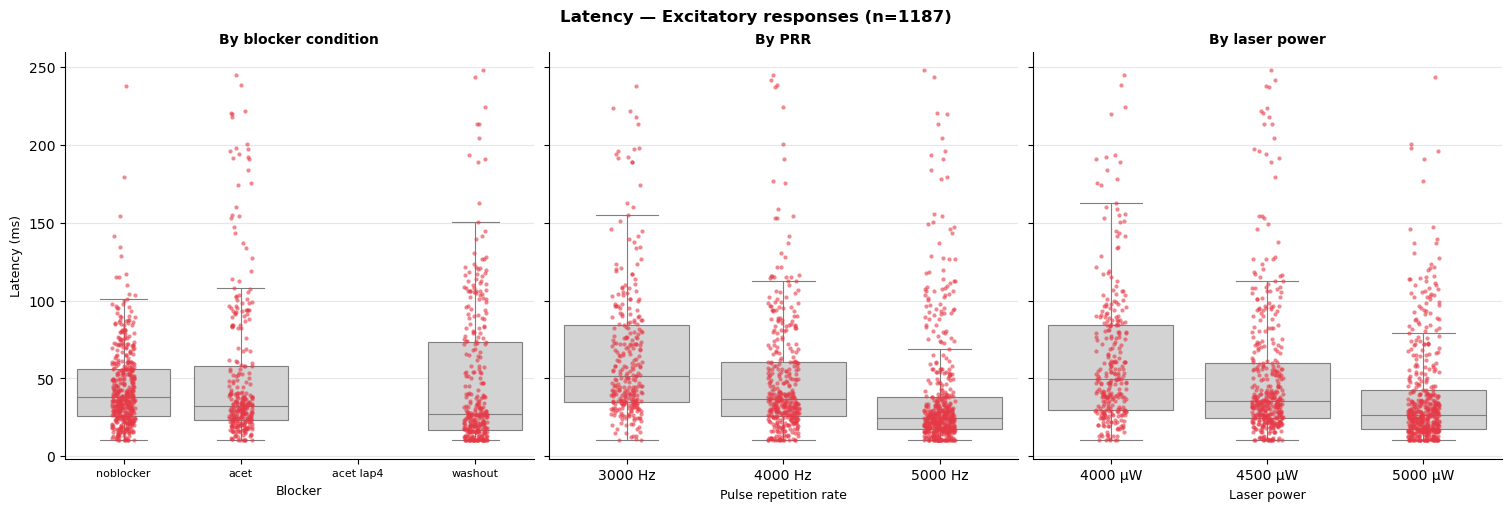

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_latency_comparison_inhibitory.png


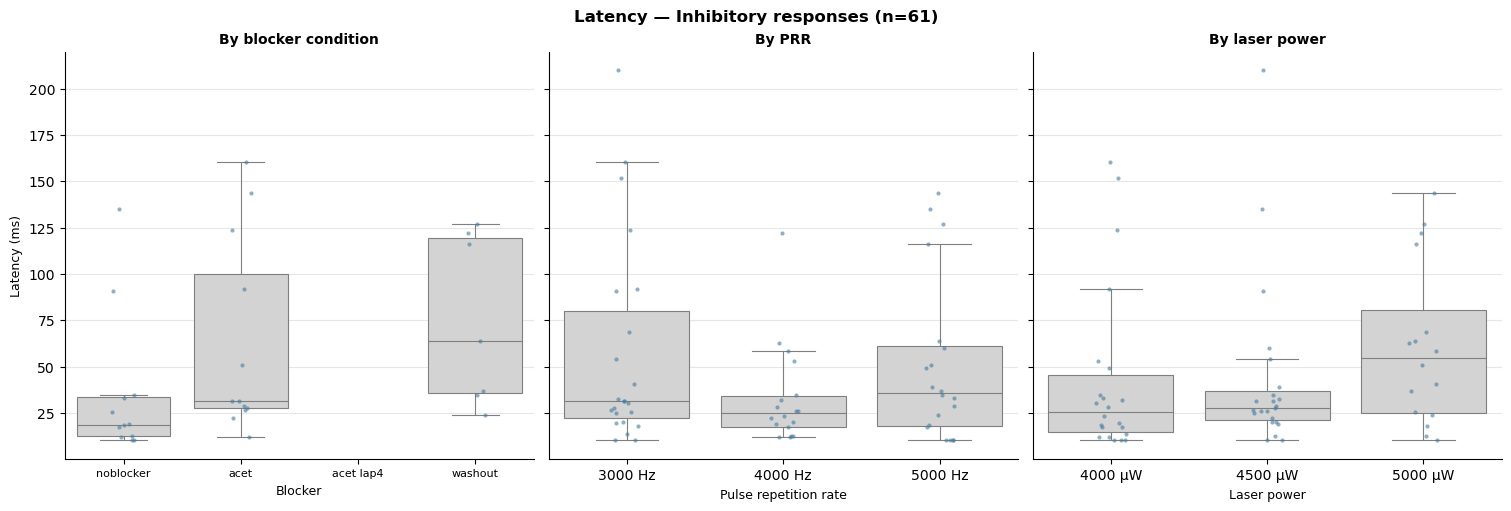

In [11]:
if df.empty:
    print('No significant responses — skipping latency plots.')
else:
    df['prr_str']   = df.prr.apply(lambda x: f'{int(x)} Hz')
    df['power_str'] = df.power.apply(lambda x: f'{int(x)} µW')

    blocker_order_str = BLOCKER_ORDER
    prr_order_str     = [f'{int(p)} Hz'  for p in prr_vals]
    power_order_str   = [f'{int(p)} µW' for p in power_vals]

    for resp_type in ['excitatory', 'inhibitory']:
        sub = df[df.response_type == resp_type]
        if sub.empty:
            print(f'No {resp_type} responses — skipping.')
            continue

        fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, constrained_layout=True)
        color = RESP_COLOR[resp_type]

        # Panel 1: vary blocker
        ax = axes[0]
        sns.boxplot(data=sub, x='blocker', y='latency_ms',
                    order=blocker_order_str, ax=ax,
                    color='lightgray', fliersize=0, linewidth=0.8)
        sns.stripplot(data=sub, x='blocker', y='latency_ms',
                      order=blocker_order_str, ax=ax,
                      color=color, jitter=True, size=3, alpha=0.6)
        ax.set_title('By blocker condition', fontsize=10, fontweight='bold')
        ax.set_xlabel('Blocker', fontsize=9)
        ax.set_ylabel('Latency (ms)', fontsize=9)
        ax.tick_params(axis='x', labelsize=8)

        # Panel 2: vary PRR
        ax = axes[1]
        sns.boxplot(data=sub, x='prr_str', y='latency_ms',
                    order=prr_order_str, ax=ax,
                    color='lightgray', fliersize=0, linewidth=0.8)
        sns.stripplot(data=sub, x='prr_str', y='latency_ms',
                      order=prr_order_str, ax=ax,
                      color=color, jitter=True, size=3, alpha=0.6)
        ax.set_title('By PRR', fontsize=10, fontweight='bold')
        ax.set_xlabel('Pulse repetition rate', fontsize=9)
        ax.set_ylabel('')

        # Panel 3: vary power
        ax = axes[2]
        sns.boxplot(data=sub, x='power_str', y='latency_ms',
                    order=power_order_str, ax=ax,
                    color='lightgray', fliersize=0, linewidth=0.8)
        sns.stripplot(data=sub, x='power_str', y='latency_ms',
                      order=power_order_str, ax=ax,
                      color=color, jitter=True, size=3, alpha=0.6)
        ax.set_title('By laser power', fontsize=10, fontweight='bold')
        ax.set_xlabel('Laser power', fontsize=9)
        ax.set_ylabel('')

        for ax in axes:
            ax.spines[['top', 'right']].set_visible(False)
            ax.grid(axis='y', alpha=0.3)

        fig.suptitle(f'Latency — {resp_type.capitalize()} responses (n={len(sub)})',
                     fontsize=12, fontweight='bold')
        fname = figure_dir / f'{session_id}_latency_comparison_{resp_type}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'Saved: {fname}')
        plt.show()

## Excitatory vs inhibitory response counts per condition
Layout: rows = PRR, columns = blocker, bars = power level.

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_response_counts_excit_vs_inhib.png


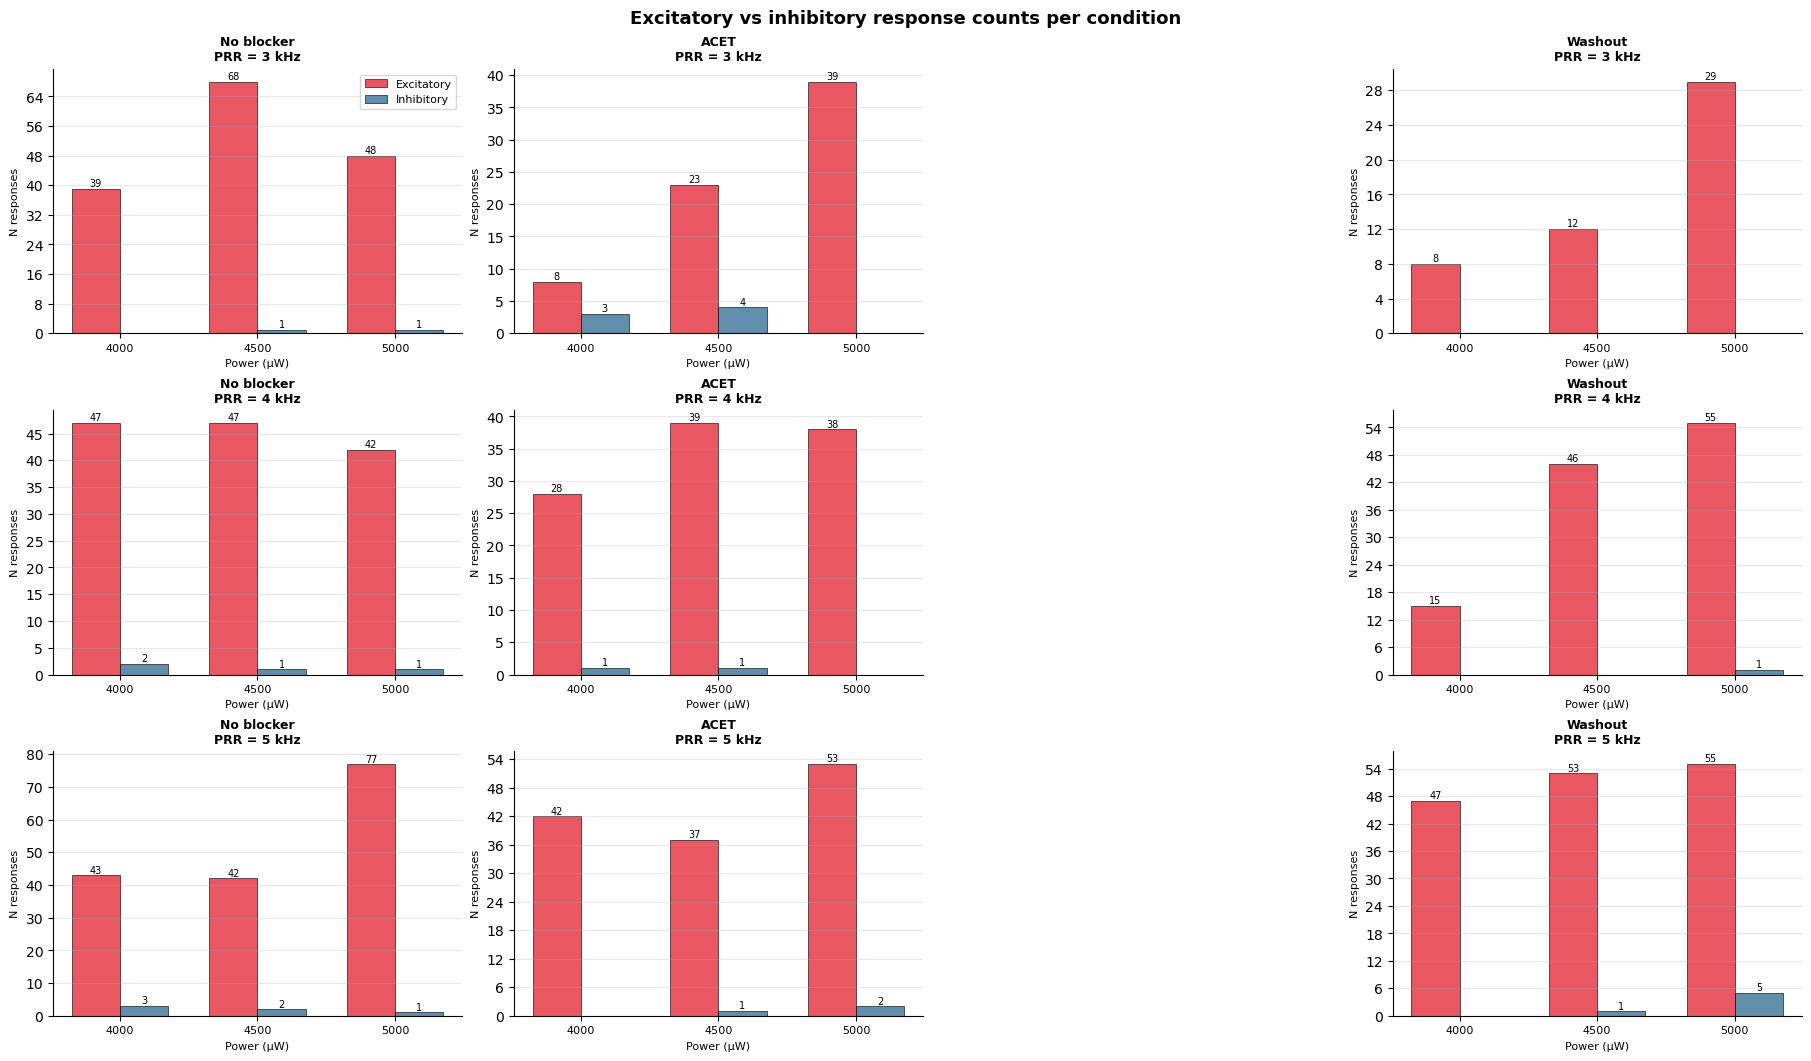

In [12]:
RESP_COLORS_CNT = {'excitatory': '#E63946', 'inhibitory': '#457B9D'}

if df.empty:
    print('No significant responses — skipping.')
else:
    fig, axes = plt.subplots(
        len(prr_vals), len(BLOCKER_ORDER),
        figsize=(4.5 * len(BLOCKER_ORDER), 3.5 * len(prr_vals)),
        constrained_layout=True,
    )

    for row_i, prr in enumerate(prr_vals):
        for col_i, blocker in enumerate(BLOCKER_ORDER):
            ax = axes[row_i, col_i]

            sub = df[(df.blocker == blocker) & (df.prr == prr)]

            if sub.empty:
                ax.set_visible(False)
                continue

            x      = np.arange(len(power_vals))
            width  = 0.35
            resp_types = ['excitatory', 'inhibitory']
            offsets    = [-width / 2, width / 2]

            for resp_type, offset in zip(resp_types, offsets):
                heights = [
                    len(sub[(sub.power == pw) & (sub.response_type == resp_type)])
                    for pw in power_vals
                ]
                bars = ax.bar(x + offset, heights, width,
                              label=resp_type.capitalize(),
                              color=RESP_COLORS_CNT[resp_type],
                              edgecolor='k', linewidth=0.5, alpha=0.85)
                for bar, h in zip(bars, heights):
                    if h > 0:
                        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                                str(int(h)), ha='center', va='bottom', fontsize=7)

            ax.set_xticks(x)
            ax.set_xticklabels([f'{int(pw)}' for pw in power_vals], fontsize=8)
            ax.set_xlabel('Power (µW)', fontsize=8)
            ax.set_ylabel('N responses', fontsize=8)
            ax.set_title(
                f'{BLOCKER_LABEL.get(blocker, blocker)}\nPRR = {int(prr/1000)} kHz',
                fontsize=9, fontweight='bold'
            )
            ax.spines[['top', 'right']].set_visible(False)
            ax.grid(axis='y', alpha=0.3)
            ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
            if row_i == 0 and col_i == 0:
                ax.legend(fontsize=8)

    fig.suptitle('Excitatory vs inhibitory response counts per condition',
                 fontsize=13, fontweight='bold')
    fname = figure_dir / f'{session_id}_response_counts_excit_vs_inhib.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname}')
    plt.show()

## ON / OFF / ON-OFF response type count per condition
Requires the Omarre cell-typing pipeline to have been run first.

In [13]:
chirp_rec_nb     = 3 - 1
typing_directory = Path(f'/media/aleong/Audrey-experiments1/Experiments/{session_id}/Analysis/CellTyping_Analysis_rec_{chirp_rec_nb}')
typing_data_path = typing_directory / f'{session_id}_PA_ACET_cell_typing_data'   # ← removed _1

try:
    typing_df = load_obj_as_df(typing_data_path)

    # Build the correct Kilosort cluster ID → sequential UID mapping from data_io
    _phy_to_uid = {
        int(row.phy_cluster_id): uid
        for uid, row in data_io.cluster_df.iterrows()
    }
    typing_df.index = [_phy_to_uid.get(int(k), f'uid_unknown_{k}') for k in typing_df.index]

    HAS_TYPING = True
    print(f'Cell typing loaded: {len(typing_df)} cells')
    print(f'Matched to recording: {sum(idx in data_io.cluster_df.index for idx in typing_df.index)} / {len(typing_df)}')
except Exception as e:
    HAS_TYPING = False
    print(f'Cell typing not available: {e}')

Cell typing loaded: 180 cells
Matched to recording: 180 / 180


Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/cell_type_counts_noblocker.png


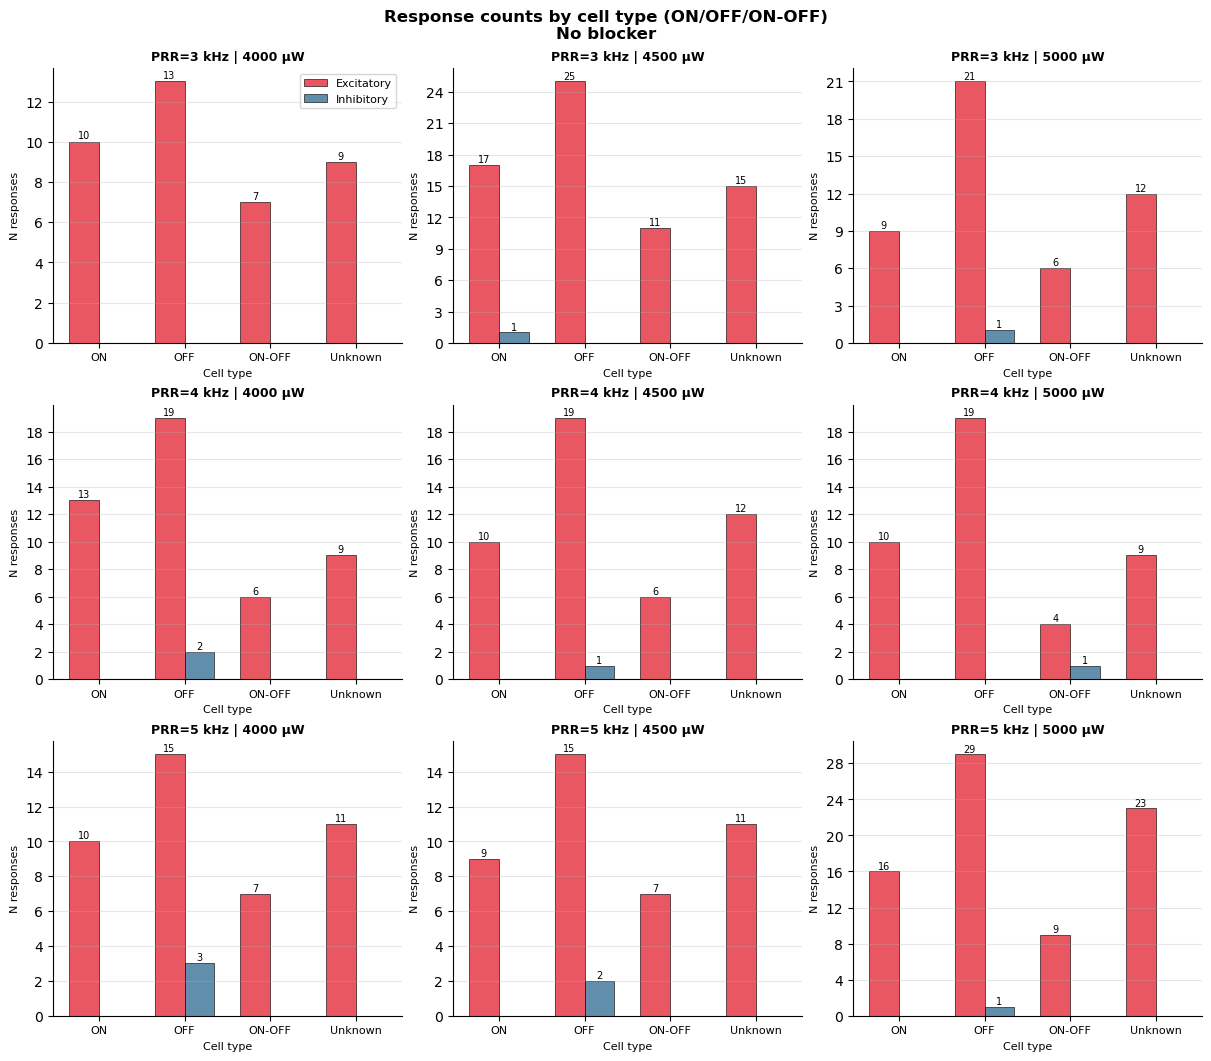

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/cell_type_counts_acet.png


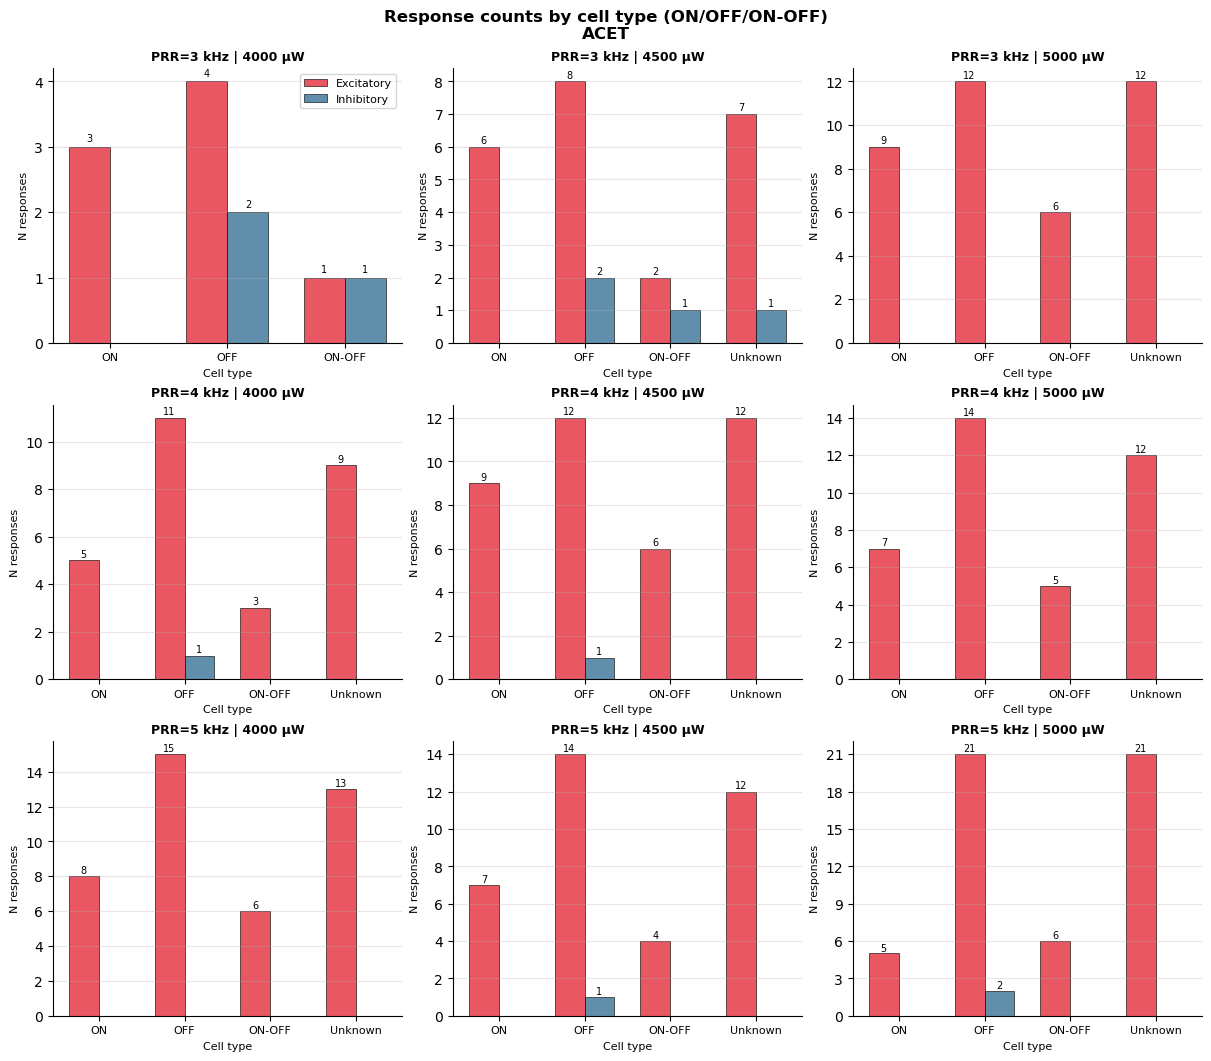

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/cell_type_counts_washout.png


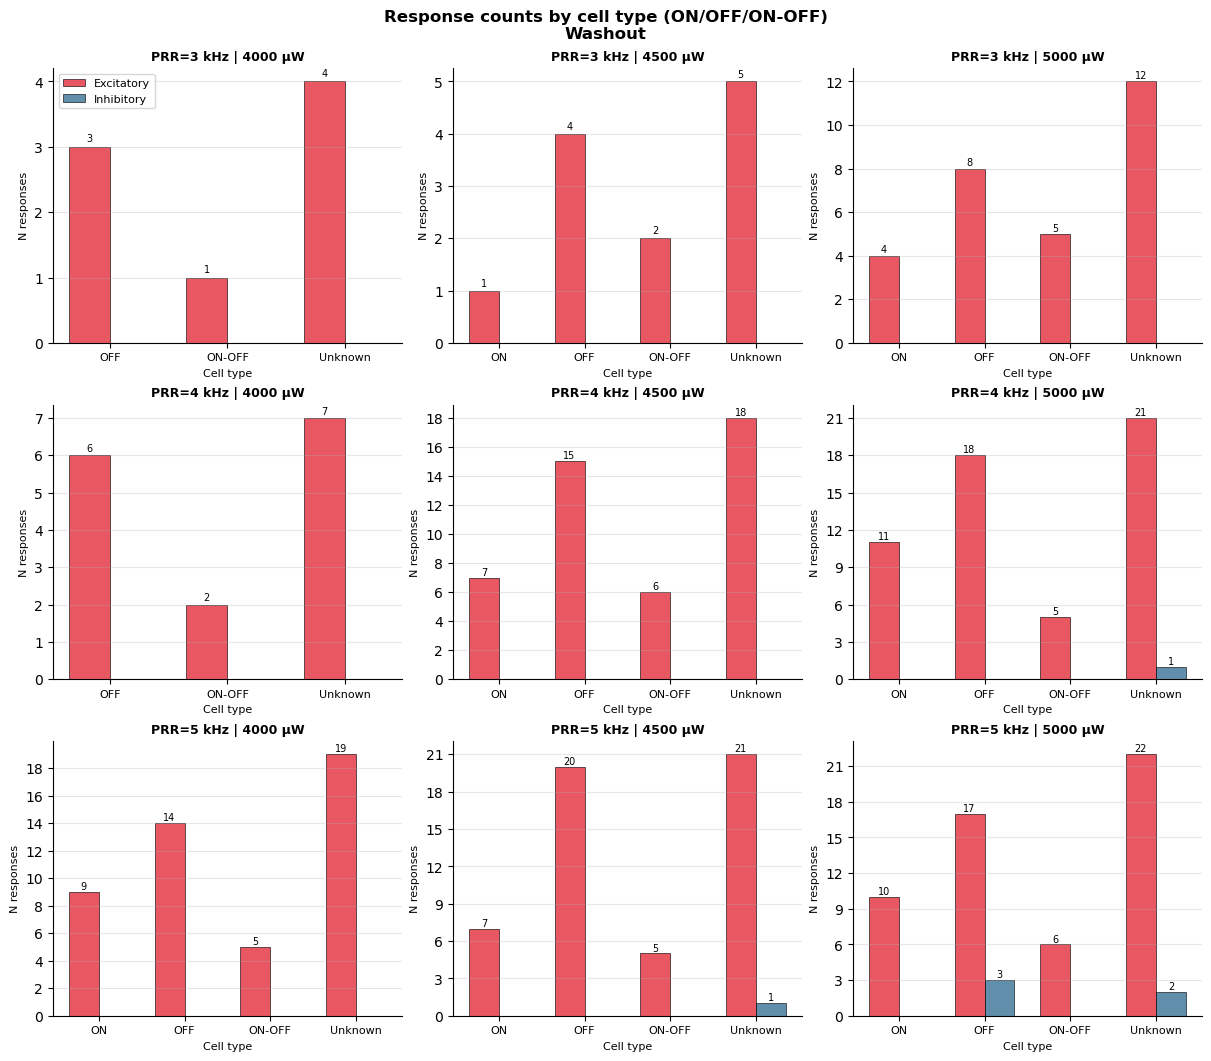

In [14]:
CT_ORDER  = ['ON', 'OFF', 'ON-OFF', 'Unknown']
CT_COLORS = {
    'ON':      '#E63946',
    'OFF':     '#457B9D',
    'ON-OFF':  '#9B59B6',
    'Unknown': '#95A5A6',
}

df = pd.read_csv(data_dir / f'{session_id}_psth_prr_series.csv')

if not HAS_TYPING or df.empty:
    print('Cell typing data or responses not available — skipping.')
else:
    df_typed = df.copy()
    df_typed['cell_type'] = df_typed.cluster_id.map(
        lambda cid: (
            extract_cell_type(typing_df.loc[cid, 'baden_type'])
            if cid in typing_df.index else None
        ) or 'Unknown'
    )

    resp_types_present = [r for r in ['excitatory', 'inhibitory']
                          if r in df_typed.response_type.unique()]

    # One figure per blocker
    for blocker in BLOCKER_ORDER:
        sub_b = df_typed[df_typed.blocker == blocker]
        if sub_b.empty:
            continue

        fig, axes = plt.subplots(
            len(prr_vals), len(power_vals),
            figsize=(4 * len(power_vals), 3.5 * len(prr_vals)),
            constrained_layout=True,
        )
        if len(prr_vals) == 1:
            axes = axes.reshape(1, -1)
        if len(power_vals) == 1:
            axes = axes.reshape(-1, 1)

        for row_i, prr in enumerate(prr_vals):
            for col_i, power in enumerate(power_vals):
                ax  = axes[row_i, col_i]
                sub = sub_b[(sub_b.prr == prr) & (sub_b.power == power)]

                if sub.empty:
                    ax.set_visible(False)
                    continue

                ct_present = [ct for ct in CT_ORDER
                              if ct in sub.cell_type.unique()]
                x      = np.arange(len(ct_present))
                width  = 0.35
                n_resp = len(resp_types_present)
                offsets = np.linspace(-(n_resp - 1) / 2, (n_resp - 1) / 2, n_resp) * width

                for resp_type, offset in zip(resp_types_present, offsets):
                    heights = [
                        len(sub[(sub.cell_type == ct) & (sub.response_type == resp_type)])
                        for ct in ct_present
                    ]
                    bars = ax.bar(
                        x + offset, heights, width,
                        label=resp_type.capitalize(),
                        color=RESP_COLORS_CNT.get(resp_type, 'gray'),
                        edgecolor='k', linewidth=0.5, alpha=0.85,
                    )
                    for bar, h in zip(bars, heights):
                        if h > 0:
                            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                                    str(int(h)), ha='center', va='bottom', fontsize=7)

                ax.set_xticks(x)
                ax.set_xticklabels(ct_present, fontsize=8)
                ax.set_xlabel('Cell type', fontsize=8)
                ax.set_ylabel('N responses', fontsize=8)
                ax.set_title(
                    f'PRR={int(prr/1000)} kHz | {int(power)} µW',
                    fontsize=9, fontweight='bold',
                )
                ax.spines[['top', 'right']].set_visible(False)
                ax.grid(axis='y', alpha=0.3)
                ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
                if row_i == 0 and col_i == 0:
                    ax.legend(fontsize=8)

        fig.suptitle(
            f'Response counts by cell type (ON/OFF/ON-OFF)\n'
            f'{BLOCKER_LABEL.get(blocker, blocker)}',
            fontsize=12, fontweight='bold',
        )
        fname = figure_dir / f'cell_type_counts_{blocker.replace(" ", "_")}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'Saved: {fname}')
        plt.show()

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_cell_type_response_counts/260519_A_cell_type_counts_overall.png


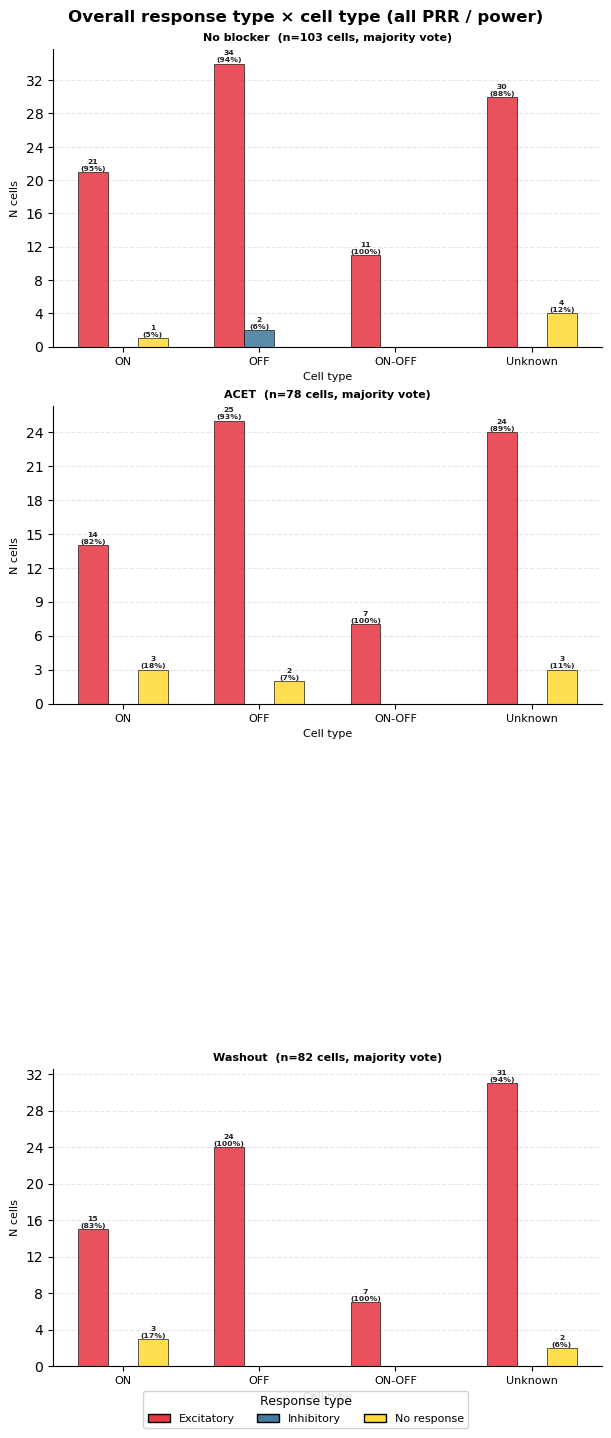

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_cell_type_response_counts/260519_A_cell_type_counts_noblocker.png


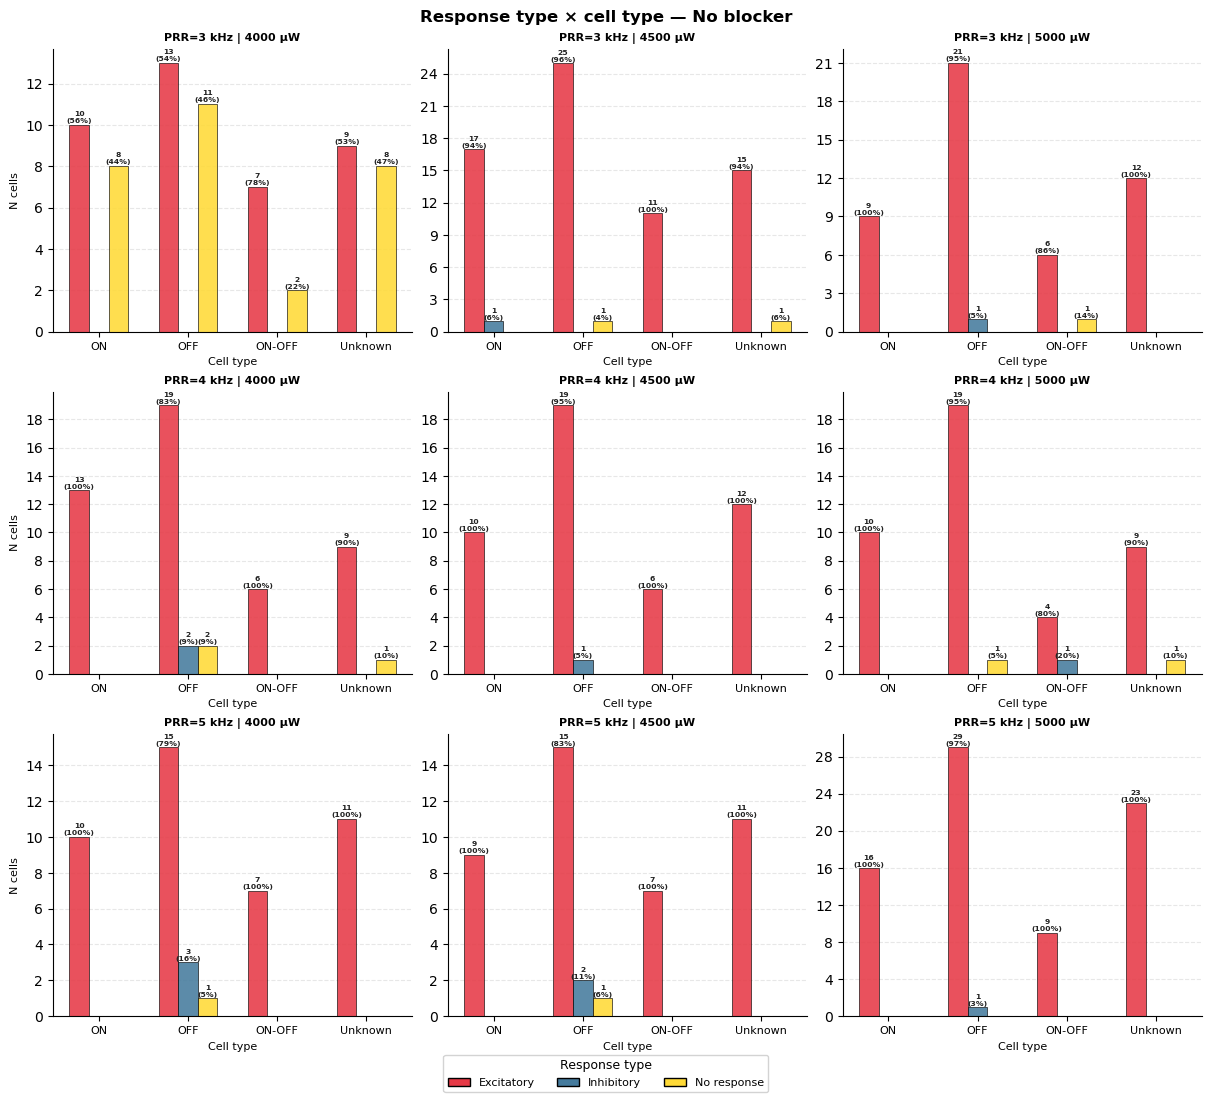

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_cell_type_response_counts/260519_A_cell_type_counts_acet.png


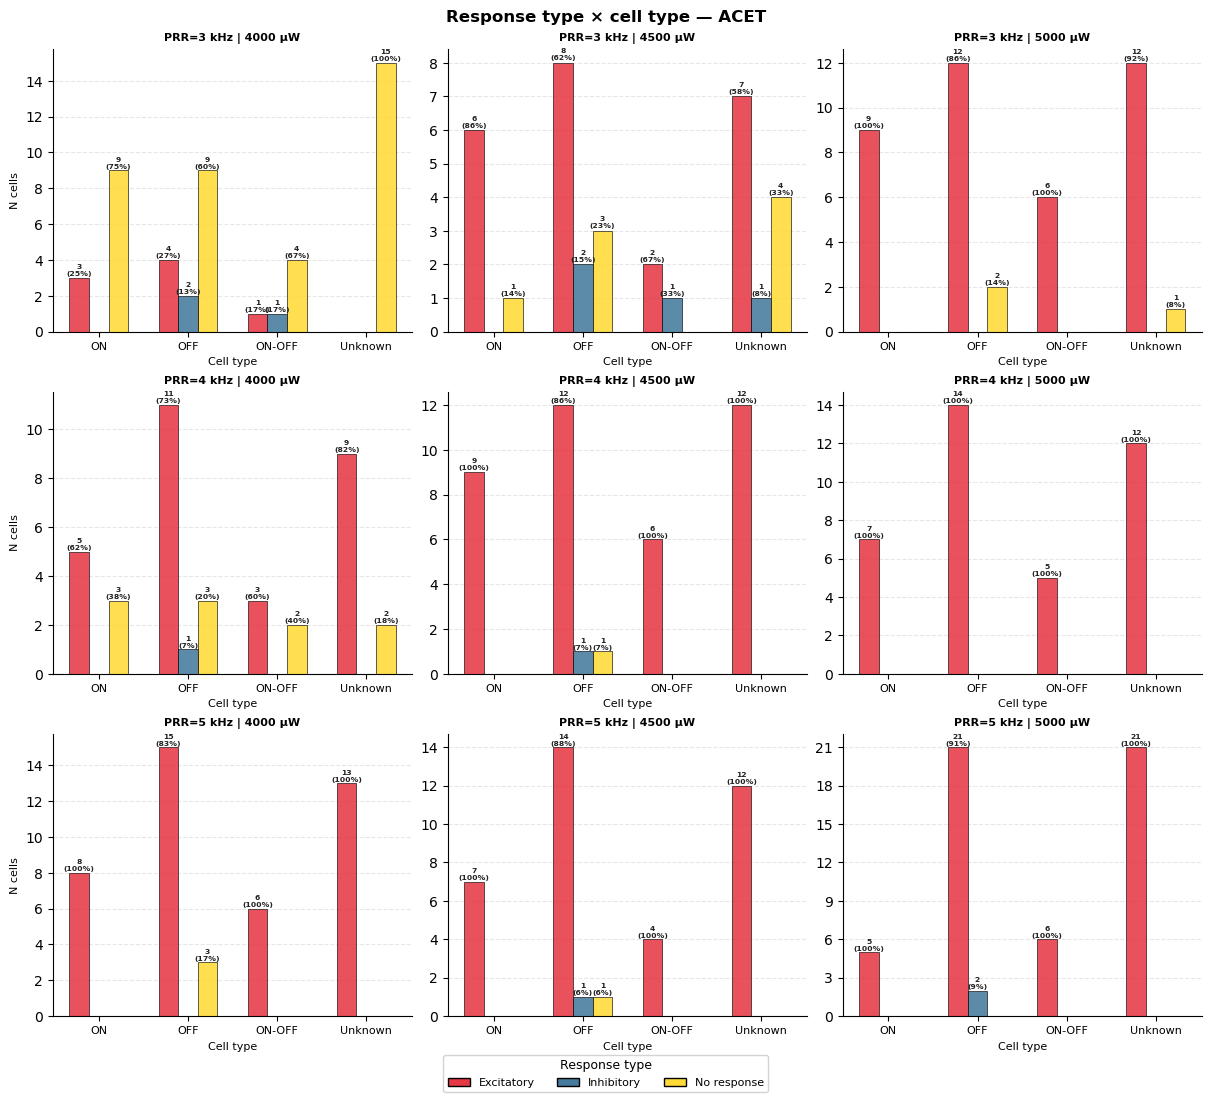

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_cell_type_response_counts/260519_A_cell_type_counts_washout.png


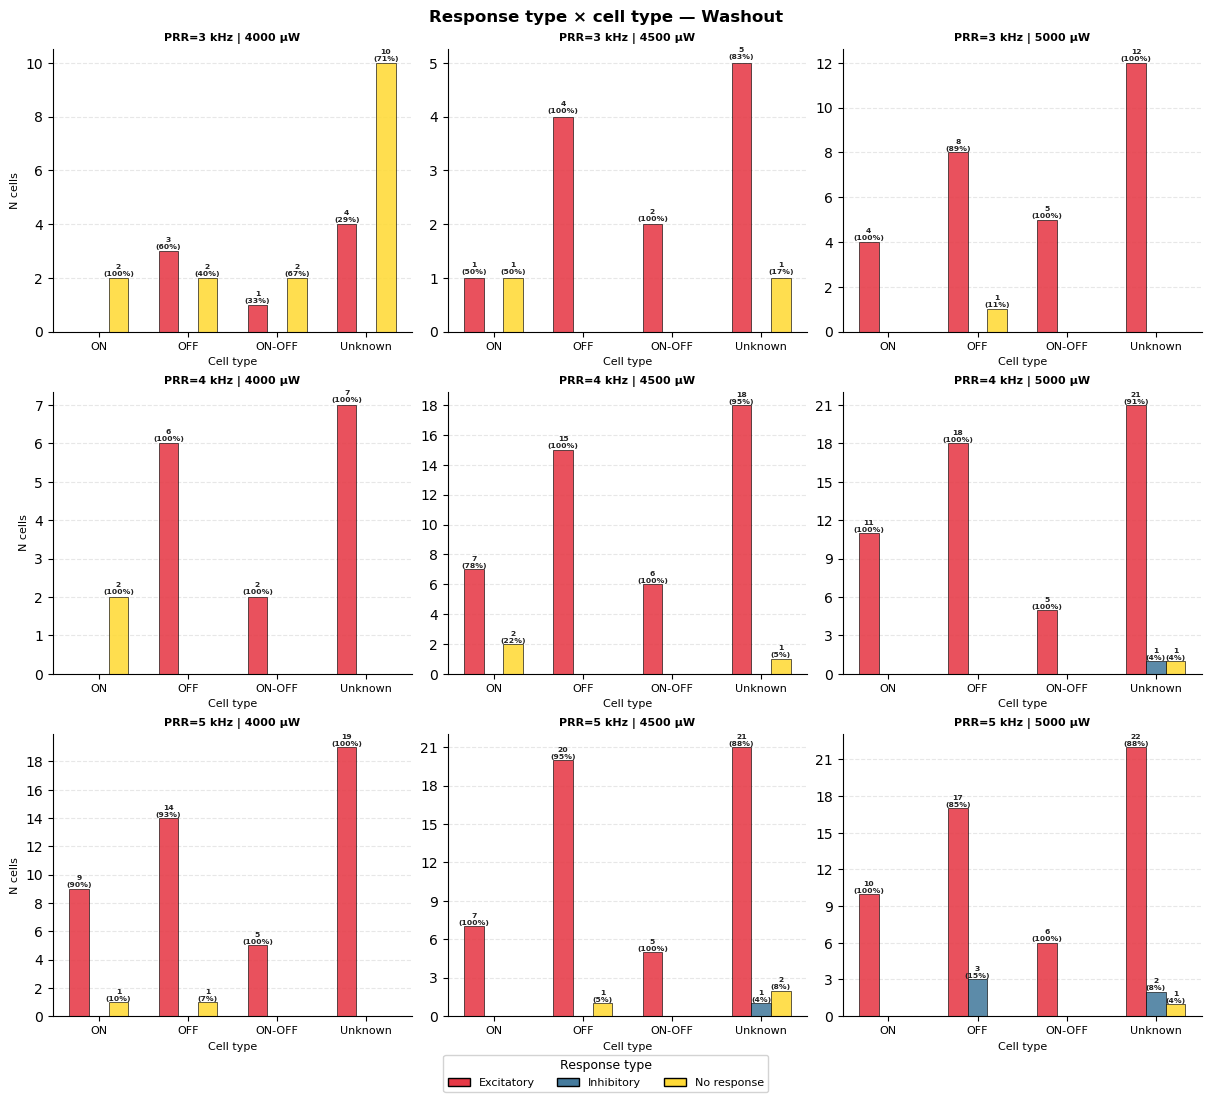

In [15]:
if not HAS_TYPING:
    print('Cell typing data not available — skipping.')
else:
    # ── Build full response table including non-responders ────────────────────
    _rows = []
    for (cid, blk, prr, pwr), d in zscore_store.items():
        resp = d['response_type'] if d['significant'] else 'none'
        _rows.append(dict(cluster_id=cid, blocker=blk,
                          prr=float(prr), power=float(pwr), response_type=resp))
    df_all = pd.DataFrame(_rows)
    df_all['cell_type'] = df_all['cluster_id'].map(
        lambda cid: (extract_cell_type(typing_df.loc[cid, 'baden_type'])
                     if cid in typing_df.index else None) or 'Unknown'
    )
    df_all['resp_label'] = df_all['response_type'].map({
        'excitatory': 'Excitatory',
        'inhibitory': 'Inhibitory',
        'none':       'No response',
    })
    CT_PRESENT = [ct for ct in CT_ORDER if ct in df_all['cell_type'].unique()]

    # ── Helpers ───────────────────────────────────────────────────────────────
    def _count_table(sub):
        ct = (
            sub.groupby(['cell_type', 'resp_label'])
            .size()
            .unstack(fill_value=0)
            .reindex(index=CT_PRESENT, columns=RESP_LABELS, fill_value=0)
        )
        ct  = ct.loc[ct.sum(axis=1) > 0]
        pct = ct.div(ct.sum(axis=1), axis=0) * 100
        return ct, pct

    def _plot_panel(ax, counts, pct, title, show_ylabel=False):
        x       = np.arange(len(counts.index))
        n_resp  = len(RESP_LABELS)
        width   = 0.22
        offsets = np.linspace(-(n_resp - 1) / 2, (n_resp - 1) / 2, n_resp) * width
        for resp, offset in zip(RESP_LABELS, offsets):
            heights = [int(counts.loc[ct, resp]) if ct in counts.index else 0
                       for ct in counts.index]
            pcts    = [pct.loc[ct, resp]          if ct in pct.index    else 0.0
                       for ct in counts.index]
            bars = ax.bar(x + offset, heights, width,
                          color=RESP_COLORS[resp], edgecolor='k',
                          linewidth=0.5, alpha=0.88, label=resp)
            for bar, h, p in zip(bars, heights, pcts):
                if h > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                            f'{h}\n({p:.0f}%)',
                            ha='center', va='bottom',
                            fontsize=5.5, fontweight='bold', color='#222')
        ax.set_xticks(x)
        ax.set_xticklabels(list(counts.index), fontsize=8)
        ax.set_xlabel('Cell type', fontsize=8)
        if show_ylabel:
            ax.set_ylabel('N cells', fontsize=8)
        ax.set_title(title, fontsize=8, fontweight='bold')
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)

    _legend_handles = [
        mpatches.Patch(facecolor=RESP_COLORS[r], edgecolor='k', label=r)
        for r in RESP_LABELS
    ]

    out_dir_ct = figure_dir / f'{session_id}_cell_type_response_counts'
    os.makedirs(out_dir_ct, exist_ok=True)

    # ── Overall figure: one row per blocker, majority vote across PRR/power ──
    fig_ov, axes_ov = plt.subplots(
        len(BLOCKER_ORDER), 1,
        figsize=(6, 3.5 * len(BLOCKER_ORDER)),
        constrained_layout=True,
    )
    for ax_ov, blocker in zip(axes_ov, BLOCKER_ORDER):
        sub_b = df_all[df_all['blocker'] == blocker]
        if sub_b.empty:
            ax_ov.set_visible(False)
            continue
        # Majority vote: most common response per cell across all PRR/power
        majority = (
            sub_b.groupby(['cluster_id', 'cell_type'])['resp_label']
            .agg(lambda s: s.mode()[0])
            .reset_index()
        )
        counts_ov, pct_ov = _count_table(majority)
        n_cells = sub_b['cluster_id'].nunique()
        _plot_panel(ax_ov, counts_ov, pct_ov,
                    f'{BLOCKER_LABEL.get(blocker, blocker)}  (n={n_cells} cells, majority vote)',
                    show_ylabel=True)

    fig_ov.legend(handles=_legend_handles, title='Response type',
                  loc='lower center', ncol=len(RESP_LABELS),
                  bbox_to_anchor=(0.5, -0.02),
                  fontsize=8, title_fontsize=9, framealpha=0.85)
    fig_ov.suptitle('Overall response type × cell type (all PRR / power)',
                    fontsize=12, fontweight='bold')
    fname_ov = out_dir_ct / f'{session_id}_cell_type_counts_overall.png'
    fig_ov.savefig(fname_ov, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname_ov}')
    plt.show()

    # ── Per-blocker figures: rows = PRR, cols = power ─────────────────────────
    for blocker in BLOCKER_ORDER:
        sub_b = df_all[df_all['blocker'] == blocker]
        if sub_b.empty:
            continue

        fig, axes = plt.subplots(
            len(prr_vals), len(power_vals),
            figsize=(4 * len(power_vals), 3.5 * len(prr_vals)),
            constrained_layout=True,
        )
        if len(prr_vals) == 1:
            axes = axes.reshape(1, -1)
        if len(power_vals) == 1:
            axes = axes.reshape(-1, 1)

        for row_i, prr in enumerate(prr_vals):
            for col_i, power in enumerate(power_vals):
                ax  = axes[row_i, col_i]
                sub = sub_b[(sub_b['prr'] == prr) & (sub_b['power'] == power)]
                if sub.empty:
                    ax.set_visible(False)
                    continue
                counts, pct = _count_table(sub)
                _plot_panel(ax, counts, pct,
                            f'PRR={int(prr/1000)} kHz | {int(power)} µW',
                            show_ylabel=(col_i == 0))

        fig.legend(handles=_legend_handles, title='Response type',
                   loc='lower center', ncol=len(RESP_LABELS),
                   bbox_to_anchor=(0.5, -0.04),
                   fontsize=8, title_fontsize=9, framealpha=0.85)
        fig.suptitle(
            f'Response type × cell type — {BLOCKER_LABEL.get(blocker, blocker)}',
            fontsize=12, fontweight='bold',
        )
        fname = out_dir_ct / f'{session_id}_cell_type_counts_{blocker.replace(" ", "_")}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'Saved: {fname}')
        plt.show()

## Light-typed cells vs PA responders — overlap
Counts how many cells carry a light-response classification (ON / OFF / ON-OFF from typing) vs
how many have a significant PA response in this experiment, and reports the intersection.

Total cells:                                 135
Light-typed (ON/OFF/ON-OFF):                 80  (59%)
PA responders (any condition):               127  (94%)
Intersection (light-typed AND PA responder): 78  (58%)
Neither:                                     6  (4%)

Intersection by cell type:
  ON      : 28 / 29  (97% of ON cells)
  OFF     : 39 / 40  (98% of OFF cells)
  ON-OFF  : 11 / 11  (100% of ON-OFF cells)

PA responders per blocker (among light-typed cells):
  No blocker            : 68 / 69 respond
  ACET                  : 47 / 51 respond
  Washout               : 46 / 49 respond

Saved: /media/aleong/Audrey-experiments1/Experiments/dataset/Figures_prr_series/260519_A_cell_type_response_counts/260519_A_light_vs_pa_overlap.png


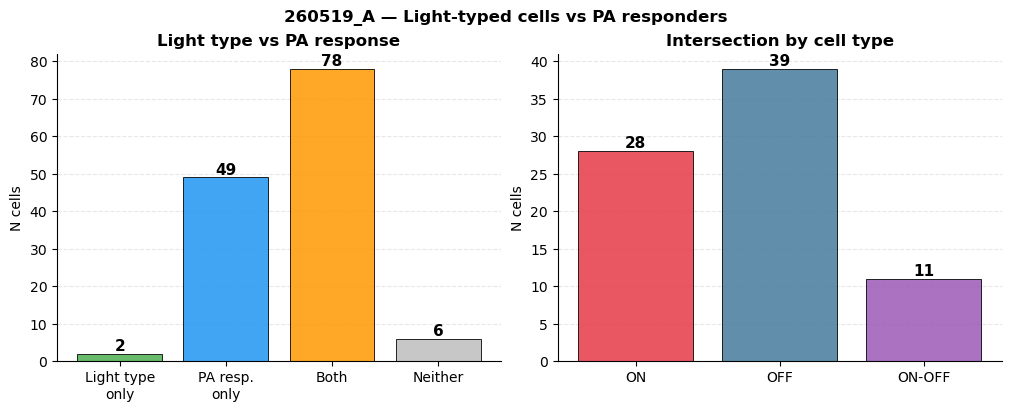

In [16]:
if not HAS_TYPING:
    print('Cell typing data not available — skipping.')
else:
    # ── Collapse to per-cell level ─────────────────────────────────────────────
    # has_pa_resp: True if ≥1 significant response in any (blocker, prr, power) condition
    _pc = (
        df_all.groupby(['cluster_id', 'cell_type'])
        .agg(has_pa_resp=('response_type', lambda s: (s != 'none').any()))
        .reset_index()
    )
    _pc['has_light_type'] = _pc['cell_type'].isin(['ON', 'OFF', 'ON-OFF'])

    n_total   = len(_pc)
    n_light   = int(_pc['has_light_type'].sum())
    n_pa      = int(_pc['has_pa_resp'].sum())
    n_both    = int((_pc['has_light_type'] & _pc['has_pa_resp']).sum())
    n_neither = n_total - n_light - n_pa + n_both

    print(f'{"Total cells:":<45}{n_total}')
    print(f'{"Light-typed (ON/OFF/ON-OFF):":<45}{n_light}  ({100*n_light/n_total:.0f}%)')
    print(f'{"PA responders (any condition):":<45}{n_pa}  ({100*n_pa/n_total:.0f}%)')
    print(f'{"Intersection (light-typed AND PA responder):":<45}{n_both}  ({100*n_both/n_total:.0f}%)')
    print(f'{"Neither:":<45}{n_neither}  ({100*n_neither/n_total:.0f}%)')

    print('\nIntersection by cell type:')
    _both_df = _pc[_pc['has_light_type'] & _pc['has_pa_resp']]
    for ct in ['ON', 'OFF', 'ON-OFF']:
        n_ct      = int((_pc['cell_type'] == ct).sum())
        n_ct_both = int((_both_df['cell_type'] == ct).sum())
        if n_ct > 0:
            print(f'  {ct:<8}: {n_ct_both} / {n_ct}  ({100*n_ct_both/n_ct:.0f}% of {ct} cells)')

    print('\nPA responders per blocker (among light-typed cells):')
    _light_ids = set(_pc.loc[_pc['has_light_type'], 'cluster_id'])
    for blk in BLOCKER_ORDER:
        sub = df_all[(df_all['blocker'] == blk) & (df_all['cluster_id'].isin(_light_ids))]
        if sub.empty:
            continue
        n_resp_blk  = int(sub.groupby('cluster_id')['response_type']
                           .apply(lambda s: (s != 'none').any()).sum())
        n_typed_blk = sub['cluster_id'].nunique()
        print(f'  {BLOCKER_LABEL.get(blk, blk):<22}: {n_resp_blk} / {n_typed_blk} respond')

    # ── Figure ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    # Left: Venn-style bar (4 exclusive groups)
    ax = axes[0]
    cats   = ['Light type\nonly', 'PA resp.\nonly', 'Both', 'Neither']
    vals   = [n_light - n_both, n_pa - n_both, n_both, n_neither]
    colors = ['#4CAF50', '#2196F3', '#FF9800', '#BDBDBD']
    bars = ax.bar(cats, vals, color=colors, edgecolor='k', linewidth=0.7, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('N cells')
    ax.set_title('Light type vs PA response', fontweight='bold')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    # Right: intersection breakdown by cell type
    ax2 = axes[1]
    ct_counts = _both_df.groupby('cell_type').size().reindex(['ON', 'OFF', 'ON-OFF'], fill_value=0)
    bars2 = ax2.bar(ct_counts.index, ct_counts.values,
                    color=[CT_COLORS.get(ct, '#888') for ct in ct_counts.index],
                    edgecolor='k', linewidth=0.7, alpha=0.85)
    for bar, v in zip(bars2, ct_counts.values):
        if v > 0:
            ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.05, str(v),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax2.set_ylabel('N cells')
    ax2.set_title('Intersection by cell type', fontweight='bold')
    ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_axisbelow(True)
    ax2.spines[['top', 'right']].set_visible(False)

    fig.suptitle(f'{session_id} — Light-typed cells vs PA responders',
                 fontsize=12, fontweight='bold')
    fname = out_dir_ct / f'{session_id}_light_vs_pa_overlap.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'\nSaved: {fname}')
    plt.show()